In [ ]:
# load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from os import listdir
import os
import numpy as np
import scipy
sns.set(style="ticks", font_scale=1.2)

In [ ]:
# TODO: include reading off the different localization procedures from path name, and getting random results from there too

In [ ]:
MODEL_MAP = {
    "meta-llama/Llama-3.1-8B": "Llama-3.1-8B", 
    "meta-llama/Llama-3.1-8B-Instruct": "Llama-3.1-8B-Instruct",
    "meta-llama/Llama-3.1-70B": "Llama-3.1-70B",
    "meta-llama/Llama-3.3-70B-Instruct": "Llama-3.3-70B-Instruct",
    "meta-llama/Llama-2-13b-hf": "Llama-2-13b",
    "meta-llama/Llama-2-13b-chat-hf": "Llama-2-13b-chat",
    "tiiuae/Falcon3-7B-Base":"Falcon3-7B",
    "tiiuae/Falcon3-7B-Instruct":"Falcon3-7B-Instruct",
    "tiiuae/Falcon3-10B-Base":"Falcon3-10B",
    "tiiuae/Falcon3-10B-Instruct":"Falcon3-10B-Instruct",
    "google/gemma-2-9b": "gemma-2-9b",
    "google/gemma-2-9b-it": "gemma-2-9b-it",
    "google/gemma-2-27b": "gemma-2-27b",
    "google/gemma-2-27b-it": "gemma-2-27b-it",
    "Qwen/Qwen2.5-7B": "Qwen2.5-7B",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen2.5-7B-Instruct",
    "Qwen/Qwen2.5-32B": "Qwen2.5-32B",
    "Qwen/Qwen2.5-32B-Instruct": "Qwen2.5-32B-Instruct",
    "Qwen/Qwen2.5-72B": "Qwen2.5-72B",
    "Qwen/Qwen2.5-72B-Instruct": "Qwen2.5-72B-Instruct"
}

blues = sns.color_palette("Blues")
reds = sns.color_palette("Reds")
greens = sns.color_palette("Greens")
oranges = sns.color_palette("Oranges")
purples = sns.color_palette("Purples")
yellows = sns.color_palette("YlOrBr")
light_blues = sns.color_palette("light:b")

MODEL_SELECTED = {
    "Llama-3.1-8B": greens[2],
    "Llama-3.1-8B-Instruct": greens[2],
    "Llama-2-13b-hf": greens[3],
    "Llama-2-13b-chat-hf": greens[3],
    "Llama-3.1-70B": greens[4],
    "Llama-3.3-70B-Instruct": greens[4],
    
    "Falcon3-7B-Base": yellows[2],
    "Falcon3-7B-Instruct": yellows[2],
    "Falcon3-10B-Base": yellows[3],
    "Falcon3-10B-Instruct": yellows[3],

    "gemma-2-9b": purples[2],
    "gemma-2-9b-it": purples[2],
    "gemma-2-27b": purples[3],
    "gemma-2-27b-it": purples[3],

    "Qwen2.5-7B": blues[2],
    "Qwen2.5-7B-Instruct": blues[2],
    "Qwen2.5-32B": blues[3],
    "Qwen2.5-32B-Instruct": blues[3],
    "Qwen2.5-72B": blues[4],
    "Qwen2.5-72B-Instruct": blues[4]
}
DATASETS = [
    "blimp",
    "tomi_sapEtAl_first_order", 
    "pub_agreement",
    "pub_indirectness_classification", 
    "fauxpas_eai_q1_and_q4",
    "ludwig",
    "opentom_attitude", 
    "hufloyd_irony",
    "imppres_presupposition",
    "pub_sarcasm",
    "pub_deictic_qa", # the only prag_discourse dataset
    "hufloyd_maxims",
    "hufloyd_metaphor",
    "imppres_implicature",
    "emobench_understanding_emotion",
    "triangle-copa",
    "ewok_agent-properties",
    "hufloyd_indirectspeech",
    "hufloyd_deceits",
    "bigtom_forward",
    "ewok_social-interactions",
    "social_iqa",
    "epitome_rm",
    "emobench_application",
    "snli",
    "entity_tracking",
    "verbal_analogies",
    "story_analogies",
]

In [ ]:
os.listdir("../lesion_test_output/cache_tom_fb_synthetic")

In [ ]:

def aggregate_over_lesioned_items(df, id_col="qid"):
    df_aggregated = df.groupby(["localizer_dataset", "localizer_type", "localization_procedure", "model", id_col]).apply(
        lambda r: 
        pd.DataFrame({
            "model_correct_mean_logprob": r["model_correct_mean_logprob"].all(),
            # "correct_lesion_sum_logprob": r["model_correct_sum_logprob"].all()
        }, index=[0])                                                
    ).reset_index()[["localizer_dataset", "localizer_type", "localization_procedure", "model", id_col, "model_correct_mean_logprob"]]

    return df_aggregated

def read_lesion_data(data_dir="../lesion_test_output/cache_tom_fb_synthetic", datasets=DATASETS, MODELS_LESIONS = list(MODEL_MAP.values())):
    results = {}
    localizers = os.listdir(data_dir)
    for localizer in localizers:
        print("Found localizer:", localizer)
        localizer_dataset = localizer.split("|")[0]
        localizer_type = "random" if "random" in localizer.split("|")[1] else "theory-of-mind"
        localization_procedure = "conjunctive" if "conjunctive" in localizer.split("|")[1] else "simple"
        dfs_localizer = []
        for dataset in datasets:
            print("loading dataset:", dataset)
            cur_dir = Path(data_dir, localizer, dataset)
            if not cur_dir.exists():
                print(f"No data found ({cur_dir}); skipping...")
                continue
            dfs = []
            for f in listdir(Path(cur_dir)):
                if not any([m in f for m in list(MODELS_LESIONS)]):
                    print(f"Uknown model in {f}")
                    continue
                try:
                    d = pd.read_csv(Path(cur_dir, f))
                except Exception as e:
                    print(f"Could not read {f} due to {e}; skipping...")
                    continue
                d["localizer_dataset"]= localizer_dataset
                d["localizer_type"]= localizer_type
                d["localization_procedure"]= localization_procedure
                d["model"] = f.split("_network")[0]
                # print("----- model type ", model_type)

                dfs.append(d)
            df = pd.concat(dfs).reset_index()
            
            # handle datasets in long format, which need grouping by item ID
            # only correct prediction if all item-level pairwise predictions are correct (therefore, these tasks have a lower chance level performance)
            # these datasets are: opentom_attitude, pub_indirectness_interpretation, social_iqa, imppres_presupposition, imppres_implicature

            
            if (dataset == "opentom_attitude") or (dataset == "social_iqa") or (dataset.startswith("imppres")): 
                df[f"model_correct_mean_logprob"] = (
                        (df[f"correct_lesion_mean_logprob"].astype(float) > df[f"incorrect_lesion_mean_logprob"].astype(float)) 
                    )
                df = aggregate_over_lesioned_items(df, id_col="id")
                df["chance"] = 1/3 
            # elif (dataset == "pub_indirectness_interpretation"): 
            #     df = aggregate_over_items(df, id_col="pretext")
            #     df["chance"] = 0.25 (in the corrected version: 1/6?)
            
            elif (dataset == "emobench_understanding_emotion"):
                df[f"model_correct_mean_logprob"] = (
                    (df[f"correct_lesion_mean_logprob"].astype(float) > df[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                df = aggregate_over_lesioned_items(df, id_col="qid")
                df["chance"] = 1/6 


            elif (dataset.startswith("emobench")):
                df[f"model_correct_mean_logprob"] = (
                    (df[f"correct_lesion_mean_logprob"].astype(float) > df[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                df = aggregate_over_lesioned_items(df, id_col="qid")
                df["chance"] = 1/5

            # Process datasets with 2x2 scoring.
            elif dataset.startswith("ewok"):
                for metric in ["mean_logprob"]:
                    if f"context1_correct_lesion_{metric}" in df.columns:
                        df[f"model_correct_{metric}"] = (
                            (df[f"context1_correct_lesion_{metric}"].astype(float) > df[f"context2_incorrect_lesion_{metric}"].astype(float)) & \
                            (df[f"context2_correct_lesion_{metric}"].astype(float) > df[f"context1_incorrect_lesion_{metric}"].astype(float))
                        )
                    # See Section 4.1 of the EWOK paper about scoring criterion
                    else:
                        df[f"model_correct_{metric}"] = (
                            (df[f"Context1_correct_lesion_{metric}"].astype(float) > df[f"Context2_incorrect_lesion_{metric}"].astype(float)) & \
                            (df[f"Context2_correct_lesion_{metric}"].astype(float) > df[f"Context1_incorrect_lesion_{metric}"].astype(float))
                        )
                df["chance"] = 0.25
            elif dataset.startswith("tinytom") or dataset.startswith("bigtom") or dataset == "epitome_fb":
                for metric in ["mean_logprob"]:
                    df[f"model_correct_{metric}"] = (
                        (df[f"fb_correct_lesion_{metric}"].astype(float) > df[f"tb_incorrect_lesion_{metric}"].astype(float)) & \
                        (df[f"tb_correct_lesion_{metric}"].astype(float) > df[f"fb_incorrect_lesion_{metric}"].astype(float))
                    )
                df["chance"] = 0.25
            elif dataset.startswith("fauxpas"):
                # print(Path(cur_dir, f))
                # print(df.columns)
                # pivot to long format, so that q1_ and q4_ columns are separate rows and accuracy will be averaged across these two conditions
                fauxpas_q1 = df[[
                    "id", "type", "story", 'question_1', 'correct_1', 'incorrect_1', 'q1_correct_lesion_mean_logprob', 'q1_incorrect_lesion_mean_logprob',
                    'q1_correct_lesion_sum_logprob',
                    'q1_incorrect_lesion_sum_logprob',
                    'q1_scored_condition', "localizer_dataset", "localizer_type", "localization_procedure", "model"
                ]].rename({
                    'question_1': 'question', 
                    'correct_1': 'correct', 
                    'incorrect_1': 'incorrect', 
                    'q1_correct_lesion_mean_logprob': 'correct_lesion_mean_logprob', 
                    'q1_incorrect_lesion_mean_logprob': 'incorrect_lesion_mean_logprob',
                    'q1_correct_lesion_sum_logprob': 'correct_lesion_sum_logprob',
                    'q1_incorrect_lesion_sum_logprob': 'incorrect_lesion_sum_logprob', 
                    'q1_scored_condition': 'scored_condition'
                }, axis = 1)
                fauxpas_q1[f"model_correct_mean_logprob"] = (
                    (fauxpas_q1[f"correct_lesion_mean_logprob"].astype(float) > fauxpas_q1[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                fauxpas_q4 = df[[
                    "id", "type", "story", 'question_4', 'correct_4', 'incorrect_4', 'q4_correct_lesion_mean_logprob', 'q4_incorrect_lesion_mean_logprob',
                    'q4_correct_lesion_sum_logprob',
                    'q4_incorrect_lesion_sum_logprob',
                    'q4_scored_condition', "localizer_dataset", "localizer_type", "localization_procedure", "model"
                ]].rename({
                    'question_4': 'question', 
                    'correct_4': 'correct', 
                    'incorrect_4': 'incorrect', 
                    'q4_correct_lesion_mean_logprob': 'correct_lesion_mean_logprob', 
                    'q4_incorrect_lesion_mean_logprob': 'incorrect_lesion_mean_logprob',
                    'q4_correct_lesion_sum_logprob': 'correct_lesion_sum_logprob',
                    'q4_incorrect_lesion_sum_logprob': 'incorrect_lesion_sum_logprob', 
                    'q4_scored_condition': 'scored_condition'
                }, axis = 1)
                fauxpas_q4[f"model_correct_mean_logprob"] = (
                    (fauxpas_q4[f"correct_lesion_mean_logprob"].astype(float) > fauxpas_q4[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                df = pd.concat([fauxpas_q1, fauxpas_q4])
                df["chance"] = 0.5
            elif (dataset.startswith("entity_tracking")):
                df[f"model_correct_mean_logprob"] = (
                    (df[f"correct_lesion_mean_logprob"].astype(float) > df[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                df = aggregate_over_lesioned_items(df, id_col="id")
                df["chance"] = 1/6
            elif (dataset.startswith("snli")):
                # assign qid by grouping by the pretext
                df["qid"] = df.groupby("pretext").ngroup()
                print("---SNLI max and min ID --- ", df["qid"].min(), df["qid"].max())
                df[f"model_correct_mean_logprob"] = (
                    (df[f"correct_lesion_mean_logprob"].astype(float) > df[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                df = aggregate_over_lesioned_items(df, id_col="qid")
                df["chance"] = 1/3
            else:
                print("----- using means ------")
                df[f"model_correct_mean_logprob"] = (
                    (df[f"correct_lesion_mean_logprob"].astype(float) > df[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                df["chance"] = 0.5
            
            # print(f"{dataset}: {len(df.index)} rows")

            df["dataset"] = dataset
            df["item_id"] = list(range(len(df)))
            dfs_localizer.append(df[["item_id", "localizer_dataset", "localizer_type", "localization_procedure", "model", "dataset", "chance", "model_correct_mean_logprob"]])
        
        loc_df = pd.concat(dfs_localizer).reset_index()
        results[localizer] = loc_df

    return results


In [ ]:
ablation_results = read_lesion_data(data_dir="../lesion_test_output/cache_tom_fb_synthetic", datasets=DATASETS, MODELS_LESIONS = list(MODEL_MAP.values()))

In [9]:
ablation_results_df = pd.concat(list(ablation_results.values()))
len(ablation_results_df)

5616488

In [10]:
ablation_results_df.head()

,index,item_id,localizer_dataset,localizer_type,localization_procedure,model,dataset,chance,model_correct_mean_logprob
0,0,0,all,theory-of-mind,conjunctive,gemma-2-27b,blimp,0.5,True
1,1,1,all,theory-of-mind,conjunctive,gemma-2-27b,blimp,0.5,True
2,2,2,all,theory-of-mind,conjunctive,gemma-2-27b,blimp,0.5,True
3,3,3,all,theory-of-mind,conjunctive,gemma-2-27b,blimp,0.5,True
4,4,4,all,theory-of-mind,conjunctive,gemma-2-27b,blimp,0.5,True


In [14]:
ablation_results_df['model'].unique()

array(['gemma-2-27b', 'gemma-2-27b-it', 'Llama-3.3-70B-Instruct',
       'Qwen2.5-32B', 'Qwen2.5-7B-Instruct', 'Falcon3-7B-Instruct',
       'Llama-3.1-8B', 'Qwen2.5-32B-Instruct', 'Qwen2.5-7B',
       'Llama-3.1-70B', 'Falcon3-10B-Base', 'gemma-2-9b', 'Qwen2.5-72B',
       'Llama-3.1-8B-Instruct', 'Qwen2.5-72B-Instruct', 'Llama-2-13b-hf',
       'Falcon3-7B-Base', 'Llama-2-13b-chat-hf', 'Falcon3-10B-Instruct',
       'gemma-2-9b-it'], dtype=object)

In [15]:
ablation_results_df_summary = ablation_results_df.groupby(["localizer_dataset", "localizer_type", "localization_procedure", "model", "dataset"], as_index=False).aggregate(
    model_correct_mean_logprob_mean=("model_correct_mean_logprob", "mean"),
    # model_correct_mean_logprob_std=("model_correct_mean_logprob", "std"),
)
ablation_results_df_summary

,localizer_dataset,localizer_type,localization_procedure,model,dataset,model_correct_mean_logprob_mean
0,all,random,conjunctive,Falcon3-10B-Base,bigtom_forward,0.447761
1,all,random,conjunctive,Falcon3-10B-Base,blimp,0.786567
2,all,random,conjunctive,Falcon3-10B-Base,emobench_application,0.560000
3,all,random,conjunctive,Falcon3-10B-Base,emobench_understanding_emotion,0.275000
4,all,random,conjunctive,Falcon3-10B-Base,entity_tracking,0.249254
...,...,...,...,...,...,...
8061,tom,theory-of-mind,simple,gemma-2-9b-it,pub_sarcasm,0.514000
8062,tom,theory-of-mind,simple,gemma-2-9b-it,snli,0.550746
8063,tom,theory-of-mind,simple,gemma-2-9b-it,social_iqa,0.502304
8064,tom,theory-of-mind,simple,gemma-2-9b-it,tomi_sapEtAl_first_order,0.750000


In [20]:
ablation_results_df_summary[ablation_results_df_summary['dataset'] == "entity_tracking"]

,localizer_dataset,localizer_type,localization_procedure,model,dataset,model_correct_mean_logprob_mean
4,all,random,conjunctive,Falcon3-10B-Base,entity_tracking,0.249254
31,all,random,conjunctive,Falcon3-10B-Instruct,entity_tracking,0.349254
56,all,random,conjunctive,Falcon3-7B-Base,entity_tracking,0.249254
83,all,random,conjunctive,Falcon3-7B-Instruct,entity_tracking,0.429851
107,all,random,conjunctive,Llama-2-13b-chat-hf,entity_tracking,0.228358
...,...,...,...,...,...,...
7843,tom,theory-of-mind,simple,Qwen2.5-32B-Instruct,entity_tracking,0.440299
7866,tom,theory-of-mind,simple,Qwen2.5-72B,entity_tracking,0.388060
7893,tom,theory-of-mind,simple,Qwen2.5-72B-Instruct,entity_tracking,0.153731
7920,tom,theory-of-mind,simple,Qwen2.5-7B,entity_tracking,0.210448


In [21]:
ablation_results_summary = ablation_results_df.groupby(["localizer_dataset", "localizer_type", "localization_procedure", "model", "dataset"]).aggregate({
    "model_correct_mean_logprob": "mean",
}).reset_index()
print("Number of ablation results:", len(ablation_results_summary))

Number of ablation results: 8066


In [22]:
ablation_results_summary.head()

,localizer_dataset,localizer_type,localization_procedure,model,dataset,model_correct_mean_logprob
0,all,random,conjunctive,Falcon3-10B-Base,bigtom_forward,0.447761
1,all,random,conjunctive,Falcon3-10B-Base,blimp,0.786567
2,all,random,conjunctive,Falcon3-10B-Base,emobench_application,0.560000
3,all,random,conjunctive,Falcon3-10B-Base,emobench_understanding_emotion,0.275000
4,all,random,conjunctive,Falcon3-10B-Base,entity_tracking,0.249254


In [23]:
len(ablation_results_summary["dataset"].unique())

28

In [104]:
baseline_results["dataset"].unique()

array(['bigtom_backward', 'bigtom_forward', 'emobench_application',
       'emobench_understanding_cause', 'emobench_understanding_emotion',
       'epitome_fb', 'epitome_rm', 'ewok_agent-properties',
       'ewok_social-interactions', 'ewok_social-properties',
       'fauxpas_eai_q1_and_q4', 'opentom_attitude',
       'opentom_location_cg_fo', 'opentom_location_cg_fo_long',
       'opentom_location_cg_so', 'opentom_location_cg_so_long',
       'opentom_location_fg_fo_new', 'opentom_location_fg_so_new',
       'opentom_multihop_fo', 'opentom_multihop_so', 'simpletom_behavior',
       'social_iqa', 'tinytom-v3_backward', 'tinytom-v3_forward',
       'tinytom-v4_backward', 'tinytom-v4_forward', 'tom_localizer',
       'tomi_fb', 'tomi_sapEtAl_first_order', 'tomi_sofb', 'tomi_tb',
       'triangle-copa', 'epitome_si', 'hufloyd_coherence',
       'hufloyd_deceits', 'hufloyd_humour', 'hufloyd_indirectspeech',
       'hufloyd_irony', 'hufloyd_maxims', 'hufloyd_metaphor',
       'imppres_impl

In [31]:
# read matching baseline data here  for plotting
baseline_results = pd.read_csv("all_model_responses_tom_pragmatics.csv")
# filter out responses of models and datasets in the lesion results
relevant_baseline_results = baseline_results[
    (baseline_results["model"].isin(list(MODEL_MAP.keys()))) & 
    (baseline_results["dataset"].isin(DATASETS))
]
relevant_baseline_results

,level_0,index,item_id,model,dataset,chance,model_correct_mean_logprob,model_correct_sum_logprob,model_type,domain,model_correct
12547,12547,1005,1005,tiiuae/Falcon3-10B-Instruct,bigtom_forward,0.25,False,False,instruct,tom,0
12548,12548,1006,1006,tiiuae/Falcon3-10B-Instruct,bigtom_forward,0.25,True,True,instruct,tom,1
12549,12549,1007,1007,tiiuae/Falcon3-10B-Instruct,bigtom_forward,0.25,False,False,instruct,tom,0
12550,12550,1008,1008,tiiuae/Falcon3-10B-Instruct,bigtom_forward,0.25,False,False,instruct,tom,0
12551,12551,1009,1009,tiiuae/Falcon3-10B-Instruct,bigtom_forward,0.25,True,True,instruct,tom,1
...,...,...,...,...,...,...,...,...,...,...,...
2920281,697745,105995,105995,Qwen/Qwen2.5-32B,pub_sarcasm,0.50,True,True,base,pragmatics,1
2920282,697746,105996,105996,Qwen/Qwen2.5-32B,pub_sarcasm,0.50,True,True,base,pragmatics,1
2920283,697747,105997,105997,Qwen/Qwen2.5-32B,pub_sarcasm,0.50,True,True,base,pragmatics,1
2920284,697748,105998,105998,Qwen/Qwen2.5-32B,pub_sarcasm,0.50,True,True,base,pragmatics,1


In [32]:
blimp_results = pd.read_csv("syntax_model_accuracy_wSNLI.csv")
relevant_blimp_results = blimp_results[
    blimp_results["model"].isin(list(MODEL_MAP.keys()))
]
relevant_blimp_results["domain"] = "syntax" # relevant_blimp_results["dataset"] #
relevant_baseline_results = pd.concat([
    relevant_baseline_results[["item_id", "model", "dataset", "chance", "model_correct_mean_logprob", "model_type", "domain", "model_correct"]], 
    relevant_blimp_results[["item_id", "model", "dataset", "chance", "model_correct_mean_logprob", "model_type", "domain", "model_correct"]]
])

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_50588/3043089722.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_blimp_results["domain"] = "syntax" # relevant_blimp_results["dataset"] #


In [33]:
len(relevant_baseline_results["dataset"].unique())
relevant_baseline_results["domain"].unique()

array(['tom', 'pragmatics', 'syntax'], dtype=object)

In [34]:
relevant_baseline_results_summary = relevant_baseline_results.groupby(["model", "dataset"]).aggregate({
    "model_correct": "mean",
}).reset_index()
print("Number of baseline results:", len(relevant_baseline_results_summary))

Number of baseline results: 500


In [38]:
480 * 16

7680

In [39]:
# map model names to lesion results
relevant_baseline_results_summary["model"] = relevant_baseline_results_summary["model"].map(MODEL_MAP)

In [ ]:
relevant_baseline_results_summary.head()

In [40]:
relevant_baseline_results_summary = relevant_baseline_results_summary.rename({
    "model_correct": "baseline_model_correct"
}, axis=1)

In [41]:
ablation_results_summary["model"] = ablation_results_summary["model"].apply(lambda s: s.replace("Falcon3-10B-Base", "Falcon3-10B").replace("Falcon3-7B-Base", "Falcon3-7B").replace('Llama-2-13b-chat-hf', 'Llama-2-13b-chat').replace('Llama-2-13b-hf', 'Llama-2-13b'))

In [42]:
relevant_baseline_results_summary["model"].unique()

array(['Qwen2.5-32B', 'Qwen2.5-32B-Instruct', 'Qwen2.5-72B',
       'Qwen2.5-72B-Instruct', 'Qwen2.5-7B', 'Qwen2.5-7B-Instruct',
       'gemma-2-27b', 'gemma-2-27b-it', 'gemma-2-9b', 'gemma-2-9b-it',
       'Llama-2-13b-chat', 'Llama-2-13b', 'Llama-3.1-70B', 'Llama-3.1-8B',
       'Llama-3.1-8B-Instruct', 'Llama-3.3-70B-Instruct', 'Falcon3-10B',
       'Falcon3-10B-Instruct', 'Falcon3-7B', 'Falcon3-7B-Instruct'],
      dtype=object)

In [43]:
ablation_results_summary["model"].unique()

array(['Falcon3-10B', 'Falcon3-10B-Instruct', 'Falcon3-7B',
       'Falcon3-7B-Instruct', 'Llama-2-13b-chat', 'Llama-2-13b',
       'Llama-3.1-70B', 'Llama-3.1-8B', 'Llama-3.1-8B-Instruct',
       'Llama-3.3-70B-Instruct', 'Qwen2.5-32B', 'Qwen2.5-32B-Instruct',
       'Qwen2.5-72B', 'Qwen2.5-72B-Instruct', 'Qwen2.5-7B',
       'Qwen2.5-7B-Instruct', 'gemma-2-27b', 'gemma-2-27b-it',
       'gemma-2-9b', 'gemma-2-9b-it'], dtype=object)

In [117]:
ablation_results_summary['dataset'].unique()
# ablation_results_summary.columns

array(['bigtom_forward', 'blimp', 'emobench_application',
       'emobench_understanding_emotion', 'entity_tracking', 'epitome_rm',
       'ewok_agent-properties', 'ewok_social-interactions',
       'fauxpas_eai_q1_and_q4', 'hufloyd_deceits',
       'hufloyd_indirectspeech', 'hufloyd_irony', 'hufloyd_maxims',
       'hufloyd_metaphor', 'imppres_implicature',
       'imppres_presupposition', 'ludwig', 'opentom_attitude',
       'pub_agreement', 'pub_deictic_qa',
       'pub_indirectness_classification', 'pub_sarcasm', 'snli',
       'social_iqa', 'story_analogies', 'triangle-copa',
       'verbal_analogies', 'tomi_sapEtAl_first_order'], dtype=object)

In [44]:
# align baseline results with lesion results
aligned_results = relevant_baseline_results_summary.merge(ablation_results_summary, on=["model", "dataset"], suffixes=("_baseline", "_lesion"))

In [46]:
aligned_results["dataset"].unique()
aligned_results.head()

,model,dataset,baseline_model_correct,localizer_dataset,localizer_type,localization_procedure,model_correct_mean_logprob
0,Qwen2.5-32B,bigtom_forward,0.641791,all,random,conjunctive,0.611940
1,Qwen2.5-32B,bigtom_forward,0.641791,all,random,simple,0.661692
2,Qwen2.5-32B,bigtom_forward,0.641791,all,theory-of-mind,conjunctive,0.631841
3,Qwen2.5-32B,bigtom_forward,0.641791,all,theory-of-mind,simple,0.651741
4,Qwen2.5-32B,bigtom_forward,0.641791,deceptive_communication,random,conjunctive,0.676617


In [ ]:
# aligned_results[aligned_results['dataset'] == "snli"]

,model,dataset,baseline_model_correct,localizer_dataset,localizer_type,localization_procedure,model_correct_mean_logprob
336,Qwen2.5-32B,snli,0.710448,all,random,conjunctive,0.664179
337,Qwen2.5-32B,snli,0.710448,all,random,simple,0.655224
338,Qwen2.5-32B,snli,0.710448,all,theory-of-mind,conjunctive,0.592537
339,Qwen2.5-32B,snli,0.710448,all,theory-of-mind,simple,0.673134
340,Qwen2.5-32B,snli,0.710448,deceptive_communication,random,conjunctive,0.653731
...,...,...,...,...,...,...,...
7304,Falcon3-7B-Instruct,snli,0.450746,strategic_games,theory-of-mind,simple,0.544776
7305,Falcon3-7B-Instruct,snli,0.450746,tom,random,conjunctive,0.546269
7306,Falcon3-7B-Instruct,snli,0.450746,tom,random,simple,0.474627
7307,Falcon3-7B-Instruct,snli,0.450746,tom,theory-of-mind,conjunctive,0.474627


In [50]:
aligned_results["delta_model_correct_mean"] = aligned_results["model_correct_mean_logprob"] - aligned_results["baseline_model_correct"] 

In [51]:
dataset_domains = {
    'bigtom_forward': "ToM", 
    'emobench_application': "ToM",
    'emobench_understanding_emotion': "ToM", 
    'epitome_rm': "ToM",
    'ewok_agent-properties': "ToM", 
    'ewok_social-interactions': "ToM",
    'fauxpas_eai_q1_and_q4': "ToM", 
    'hufloyd_deceits': "pragmatics",
    'hufloyd_indirectspeech': "pragmatics", 
    'hufloyd_irony': "pragmatics", 
    'hufloyd_maxims': "pragmatics",
    'hufloyd_metaphor': "pragmatics", 
    'imppres_implicature': "pragmatics",
    'imppres_presupposition': "pragmatics", 
    'ludwig': "pragmatics", 
    'opentom_attitude': "ToM",
    'pub_agreement': "pragmatics", 
    'pub_deictic_qa': "pragmatics",
    'pub_indirectness_classification': "pragmatics", 
    'pub_sarcasm': "pragmatics", 
    'social_iqa': "ToM",
    'triangle-copa': "ToM", 
    'tomi_sapEtAl_first_order': "pragmatics",
    'blimp': "syntax",
    'snli': "syntax",
    'story_analogies': "syntax",
    'verbal_analogies': "syntax",
    'entity_tracking': "syntax"
}


In [52]:
aligned_results["localizer"] = aligned_results["localizer_dataset"] + "_" + aligned_results["localization_procedure"] 
aligned_results["domain"] = aligned_results["dataset"].map(dataset_domains)
aligned_results.head()

,model,dataset,baseline_model_correct,localizer_dataset,localizer_type,localization_procedure,model_correct_mean_logprob,delta_model_correct_mean,localizer,domain
0,Qwen2.5-32B,bigtom_forward,0.641791,all,random,conjunctive,0.611940,-0.029851,all_conjunctive,ToM
1,Qwen2.5-32B,bigtom_forward,0.641791,all,random,simple,0.661692,0.019900,all_simple,ToM
2,Qwen2.5-32B,bigtom_forward,0.641791,all,theory-of-mind,conjunctive,0.631841,-0.009950,all_conjunctive,ToM
3,Qwen2.5-32B,bigtom_forward,0.641791,all,theory-of-mind,simple,0.651741,0.009950,all_simple,ToM
4,Qwen2.5-32B,bigtom_forward,0.641791,deceptive_communication,random,conjunctive,0.676617,0.034826,deceptive_communication_conjunctive,ToM


In [53]:
aligned_results["localizer"] = pd.Categorical(aligned_results["localizer"], categories=[
    "tom_simple", "deceptive_communication_simple", "strategic_games_simple", "all_simple",
    "tom_conjunctive", "deceptive_communication_conjunctive","moral_intent_simple" , "all_conjunctive"]
)
aligned_results["localizer"] = aligned_results["localizer"].cat.rename_categories({
    "tom_simple": "LatentBeliefs (simple)", 
    "deceptive_communication_simple": "CommunicativeIntent (simple)", 
    "strategic_games_simple": "GameBeliefs (simple)", 
    "all_simple": "All (simple)",
    "tom_conjunctive": "LatentBeliefs (conjunctive)", 
    "deceptive_communication_conjunctive": "CommunicativeIntent (conjunctive)",
    "moral_intent_simple": "MoralIntent (simple)",
    "all_conjunctive": "LB + CI (conjunctive)"
})

In [54]:
aligned_results["localizer_type"] = aligned_results["localizer_type"].apply(lambda s: "critical" if s == "theory-of-mind" else s)
aligned_results["localizer_type"] = aligned_results["localizer_type"].apply(lambda s: "least active" if s == "random" else s)
aligned_results["localizer_type"] = pd.Categorical(aligned_results["localizer_type"], categories=['critical', 'least active'])

In [55]:
aligned_results["model_type"] = aligned_results["model"].apply(lambda s: "instruct" if ("instruct" in s.lower()) or ("-it" in s.lower()) or ("chat" in s.lower()) else "base") 
aligned_results

,model,dataset,baseline_model_correct,localizer_dataset,localizer_type,localization_procedure,model_correct_mean_logprob,delta_model_correct_mean,localizer,domain,model_type
0,Qwen2.5-32B,bigtom_forward,0.641791,all,least active,conjunctive,0.611940,-0.029851,LB + CI (conjunctive),ToM,base
1,Qwen2.5-32B,bigtom_forward,0.641791,all,least active,simple,0.661692,0.019900,All (simple),ToM,base
2,Qwen2.5-32B,bigtom_forward,0.641791,all,critical,conjunctive,0.631841,-0.009950,LB + CI (conjunctive),ToM,base
3,Qwen2.5-32B,bigtom_forward,0.641791,all,critical,simple,0.651741,0.009950,All (simple),ToM,base
4,Qwen2.5-32B,bigtom_forward,0.641791,deceptive_communication,least active,conjunctive,0.676617,0.034826,CommunicativeIntent (conjunctive),ToM,base
...,...,...,...,...,...,...,...,...,...,...,...
7336,Falcon3-7B-Instruct,triangle-copa,0.760000,strategic_games,critical,simple,0.660000,-0.100000,GameBeliefs (simple),ToM,instruct
7337,Falcon3-7B-Instruct,triangle-copa,0.760000,tom,least active,conjunctive,0.740000,-0.020000,LatentBeliefs (conjunctive),ToM,instruct
7338,Falcon3-7B-Instruct,triangle-copa,0.760000,tom,least active,simple,0.730000,-0.030000,LatentBeliefs (simple),ToM,instruct
7339,Falcon3-7B-Instruct,triangle-copa,0.760000,tom,critical,conjunctive,0.710000,-0.050000,LatentBeliefs (conjunctive),ToM,instruct


In [ ]:
aligned_results[aligned_results["model_correct_mean_logprob"].isna()]

In [ ]:
# aligned_results.to_csv("ablation_results_summary_wSNLI.csv", index=False)

In [57]:
aligned_results_across_datasets = aligned_results.groupby(["localizer_dataset", "localizer_type", "localization_procedure", "localizer", "model", "domain"]).aggregate({
    "delta_model_correct_mean": "mean",
    "baseline_model_correct": "mean",
    "model_correct_mean_logprob": "mean"
}).reset_index()
aligned_results_across_datasets.head()

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_50588/3603464992.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aligned_results_across_datasets = aligned_results.groupby(["localizer_dataset", "localizer_type", "localization_procedure", "localizer", "model", "domain"]).aggregate({


,localizer_dataset,localizer_type,localization_procedure,localizer,model,domain,delta_model_correct_mean,baseline_model_correct,model_correct_mean_logprob
0,all,critical,conjunctive,LatentBeliefs (simple),Falcon3-10B,ToM,NaN,NaN,NaN
1,all,critical,conjunctive,LatentBeliefs (simple),Falcon3-10B,pragmatics,NaN,NaN,NaN
2,all,critical,conjunctive,LatentBeliefs (simple),Falcon3-10B,syntax,NaN,NaN,NaN
3,all,critical,conjunctive,LatentBeliefs (simple),Falcon3-10B-Instruct,ToM,NaN,NaN,NaN
4,all,critical,conjunctive,LatentBeliefs (simple),Falcon3-10B-Instruct,pragmatics,NaN,NaN,NaN


In [58]:
aligned_results_across_datasets["localizer_type"] = aligned_results_across_datasets["localizer_type"].apply(lambda s: "critical" if s == "theory-of-mind" else s)
aligned_results_across_datasets["localizer_type"] = aligned_results_across_datasets["localizer_type"].apply(lambda s: "least active" if s == "random" else s)

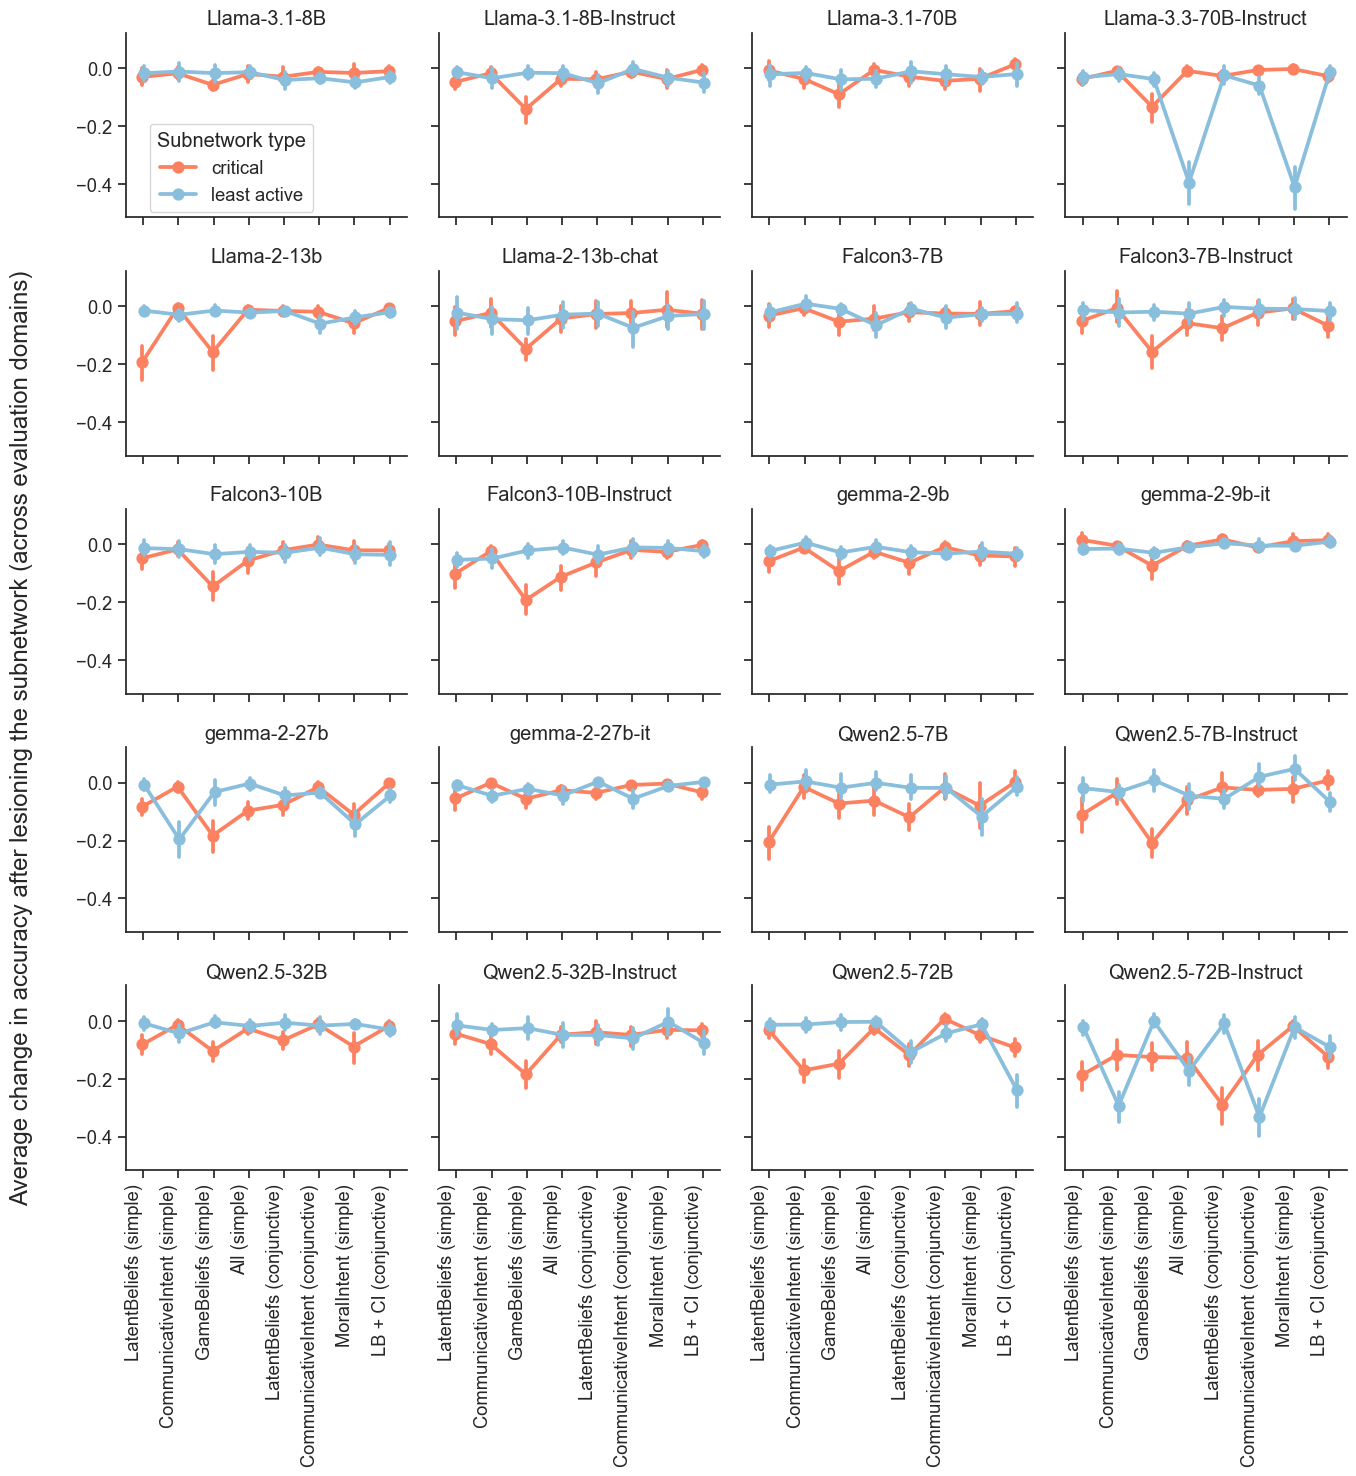

In [59]:
# TODO: is this averaged across ToM, pragmatics, syntax datasets?
g = sns.catplot(
    data=aligned_results,
    kind="point",
    x="localizer",
    y="delta_model_correct_mean",
    hue="localizer_type",
    col="model",
    col_wrap=4,
    col_order=list(MODEL_MAP.values()),
    hue_order=["critical", "least active"],
    palette={
        "least active": blues[2],
        "critical": reds[2],
        # "syntax": greens[2],
    },
    dodge=True,
    errorbar=("ci", 95),
    height=3,
    aspect=1,
    legend=True,
)
for ax in g.axes.flatten():
    # ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for label in ax.get_xticklabels():
        label.set_rotation(90)
        label.set_ha('right')
    # ax.set_ylabel("Average change in accuracy after lesioning the subnetwork (across localizers)")
for ax, model_name in zip(g.axes.flat, g.col_names):
    ax.set_title(f"{model_name}")

sns.move_legend(
    g,
    "center right",
    bbox_to_anchor=(0.23, 0.88),  # (x, y) offset relative to axes
    frameon=True,
    title="Subnetwork type"
)
# shared y-axis label
g.fig.supylabel(
    "Average change in accuracy after lesioning the subnetwork (across evaluation domains)",
    x=0.00  # tweak if needed
)
plt.tight_layout()
    

In [79]:
aligned_results['domain'] = aligned_results["domain"].map({
    "pragmatics": "Pragmatics",
    "ToM": "ToM",
    "syntax": "Linguistic abilities"
})

In [86]:
aligned_results_part1 = aligned_results[
    aligned_results["model"].isin(list(MODEL_MAP.values())[:10])
]
len(aligned_results_part1["model"].unique())

10

In [89]:
aligned_results_part1['domain'].unique()

array(['ToM', 'Linguistic abilities', 'Pragmatics'], dtype=object)

In [81]:
aligned_results_part2 = aligned_results[
    aligned_results["model"].isin(list(MODEL_MAP.values())[10:])
]
len(aligned_results_part2["model"].unique())
aligned_results_part1

,model,dataset,baseline_model_correct,localizer_dataset,localizer_type,localization_procedure,model_correct_mean_logprob,delta_model_correct_mean,localizer,domain,model_type
3741,Llama-2-13b-chat,bigtom_forward,0.58209,all,least active,conjunctive,0.512438,-0.069652,LB + CI (conjunctive),ToM,instruct
3742,Llama-2-13b-chat,bigtom_forward,0.58209,all,least active,simple,0.457711,-0.124378,All (simple),ToM,instruct
3743,Llama-2-13b-chat,bigtom_forward,0.58209,all,critical,conjunctive,0.562189,-0.019900,LB + CI (conjunctive),ToM,instruct
3744,Llama-2-13b-chat,bigtom_forward,0.58209,all,critical,simple,0.388060,-0.194030,All (simple),ToM,instruct
3745,Llama-2-13b-chat,bigtom_forward,0.58209,deceptive_communication,least active,conjunctive,0.348259,-0.233831,CommunicativeIntent (conjunctive),ToM,instruct
...,...,...,...,...,...,...,...,...,...,...,...
7336,Falcon3-7B-Instruct,triangle-copa,0.76000,strategic_games,critical,simple,0.660000,-0.100000,GameBeliefs (simple),ToM,instruct
7337,Falcon3-7B-Instruct,triangle-copa,0.76000,tom,least active,conjunctive,0.740000,-0.020000,LatentBeliefs (conjunctive),ToM,instruct
7338,Falcon3-7B-Instruct,triangle-copa,0.76000,tom,least active,simple,0.730000,-0.030000,LatentBeliefs (simple),ToM,instruct
7339,Falcon3-7B-Instruct,triangle-copa,0.76000,tom,critical,conjunctive,0.710000,-0.050000,LatentBeliefs (conjunctive),ToM,instruct


In [ ]:
list(MODEL_MAP.values())[10:]

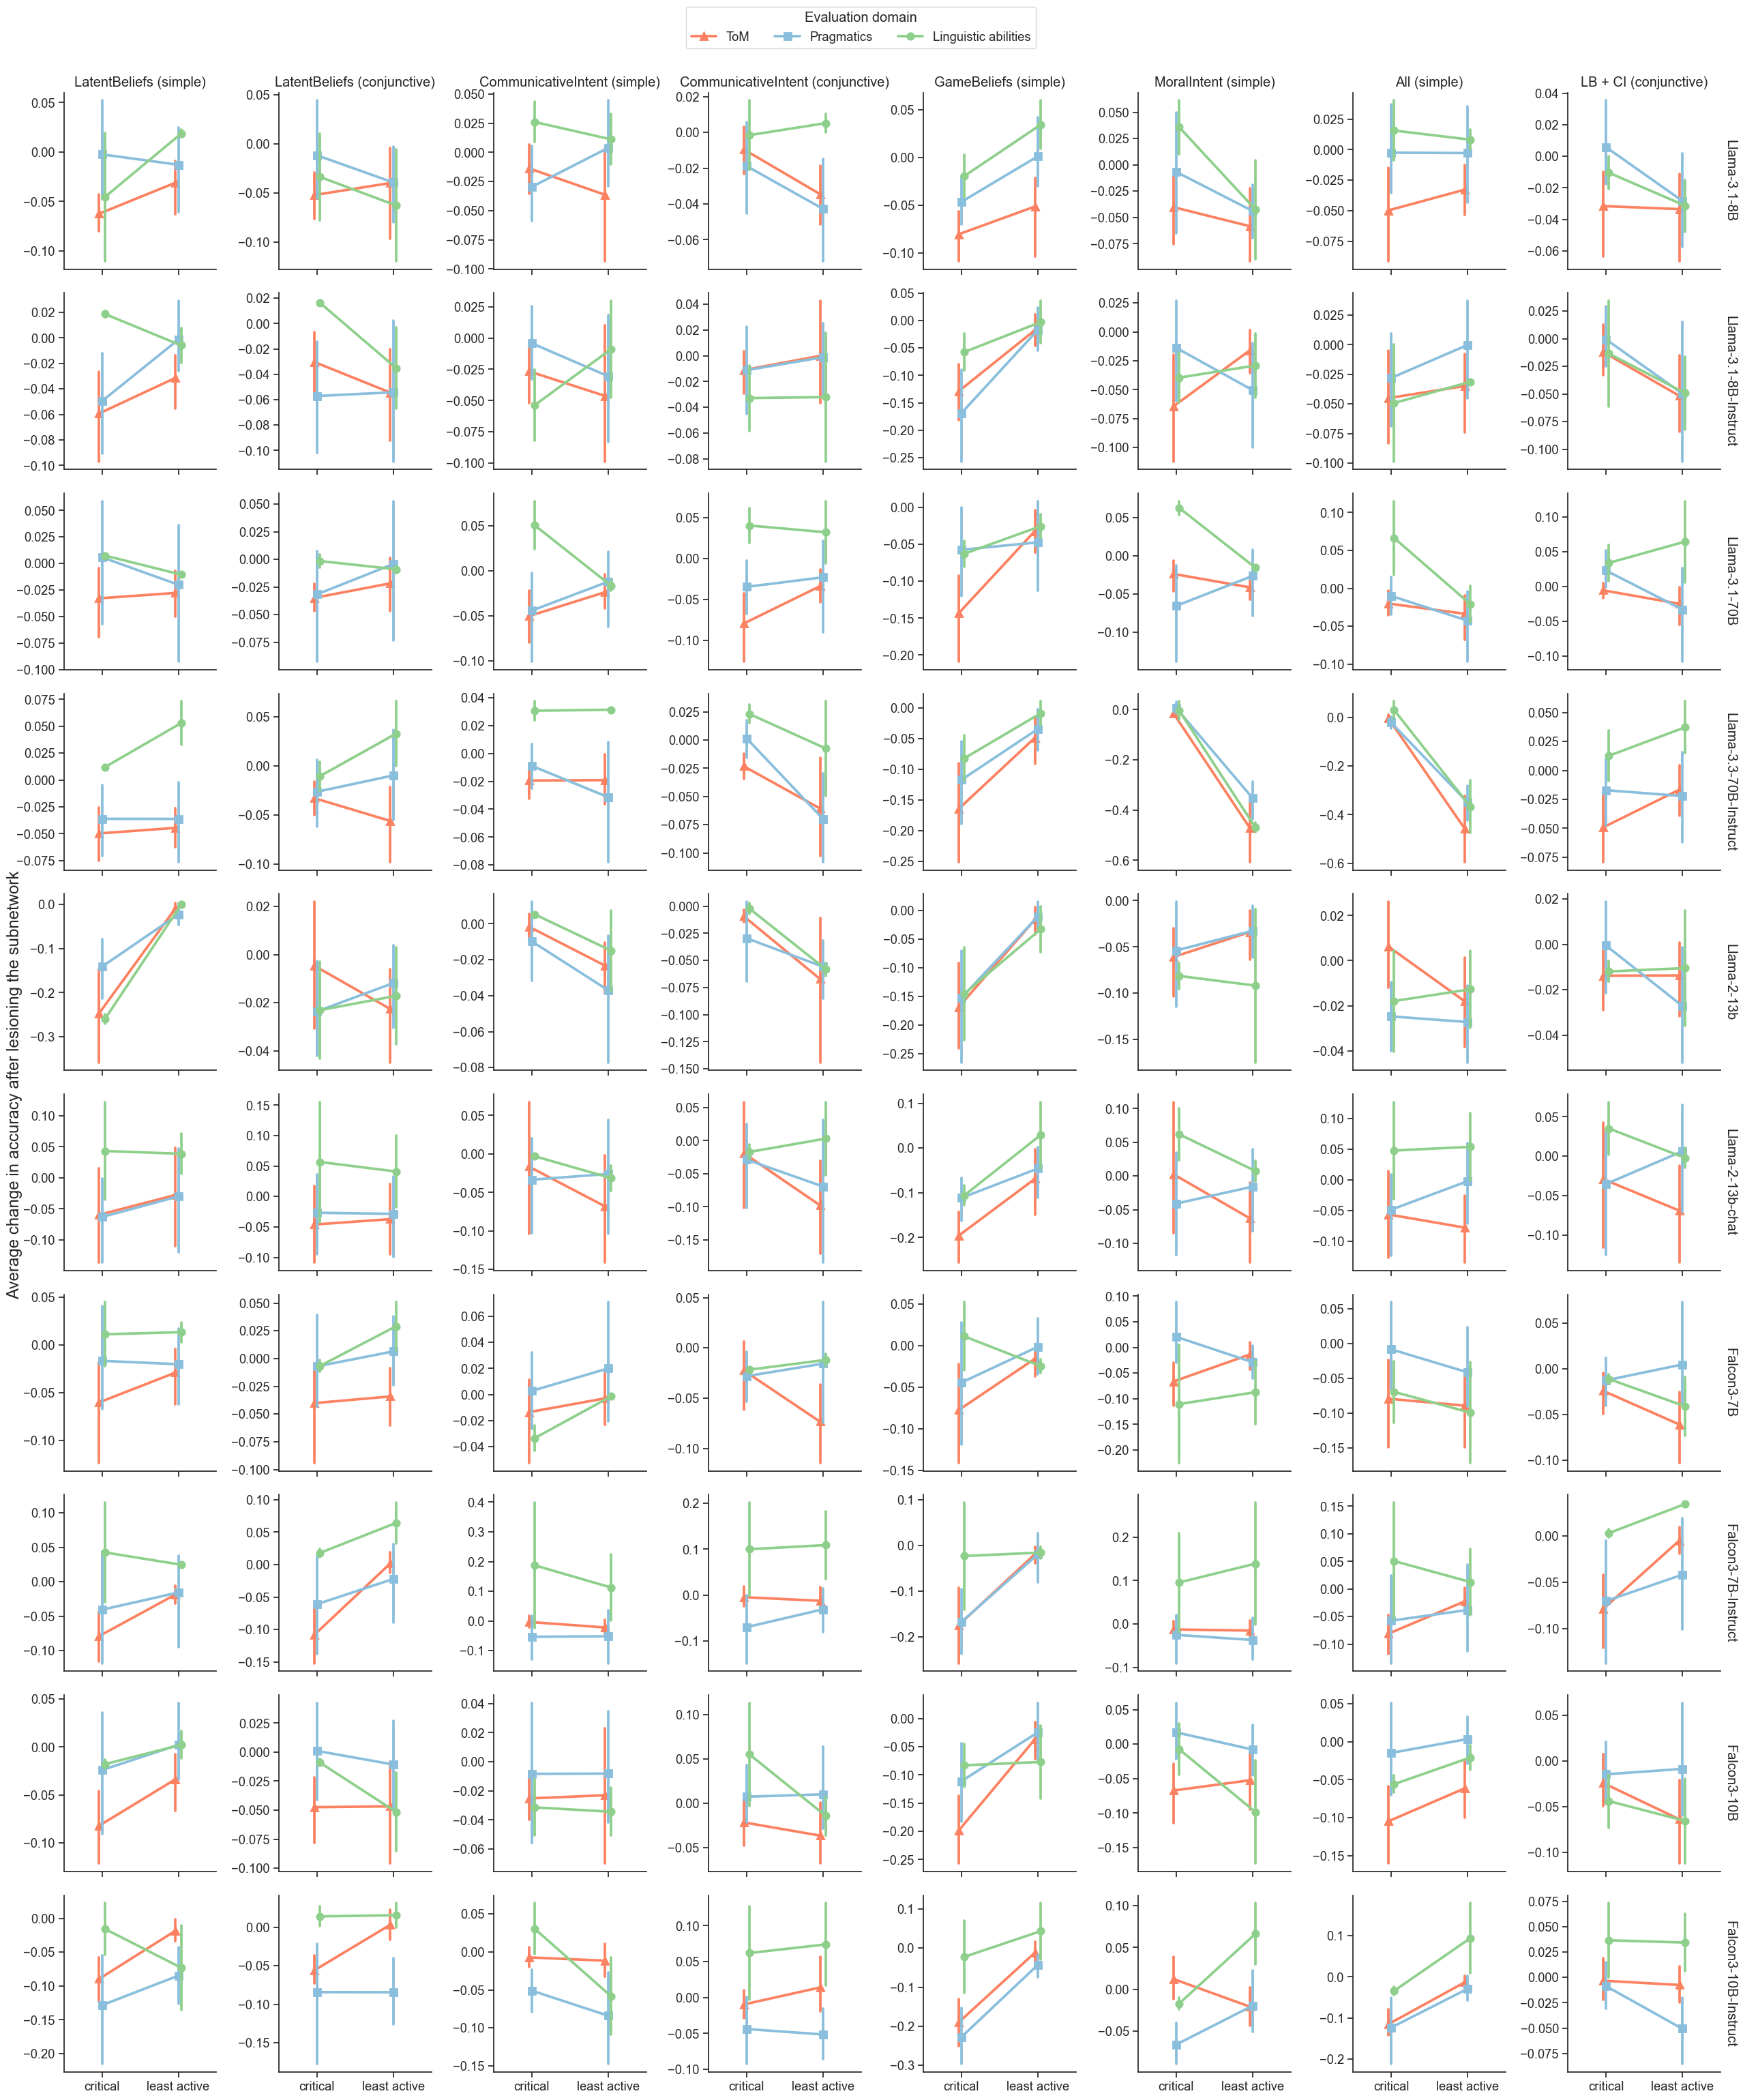

In [90]:
# TODO: is this averaged across ToM, pragmatics, syntax datasets?
g = sns.catplot(
    data=aligned_results_part1,
    kind="point",
    x="localizer_type",
    y="delta_model_correct_mean",
    hue="domain",
    col="localizer",
    row="model",
    # col_wrap=4,
    row_order=list(MODEL_MAP.values())[:10],
    col_order= ["LatentBeliefs (simple)", "LatentBeliefs (conjunctive)",  "CommunicativeIntent (simple)", "CommunicativeIntent (conjunctive)","GameBeliefs (simple)", "MoralIntent (simple)", "All (simple)","LB + CI (conjunctive)"],
    hue_order=["ToM", "Pragmatics", "Linguistic abilities"],
    markers=["^", "s", "o"],
    palette={
        "Pragmatics": blues[2],
        "ToM": reds[2],
        "Linguistic abilities": greens[2],
    },
    dodge=True,
    errorbar=("ci", 95),
    height=3,
    aspect=1,
    legend=True,
    margin_titles=True,
    sharey=False
)
for ax in g.axes.flatten():
    # ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        # label.set_ha('right')
    # ax.set_ylabel("Average change in accuracy after lesioning the subnetwork (across localizers)")
g.set_titles(col_template="{col_name}", row_template="{row_name}")

sns.move_legend(
    g,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),   # centered above the grid
    ncol=len(g._legend_data),     # horizontal layout
    frameon=True,
    title="Evaluation domain"
)
# shared y-axis label
g.fig.supylabel(
    "Average change in accuracy after lesioning the subnetwork",
    x=0.02  # tweak if needed
)
plt.tight_layout()
    

In [ ]:
aligned_results

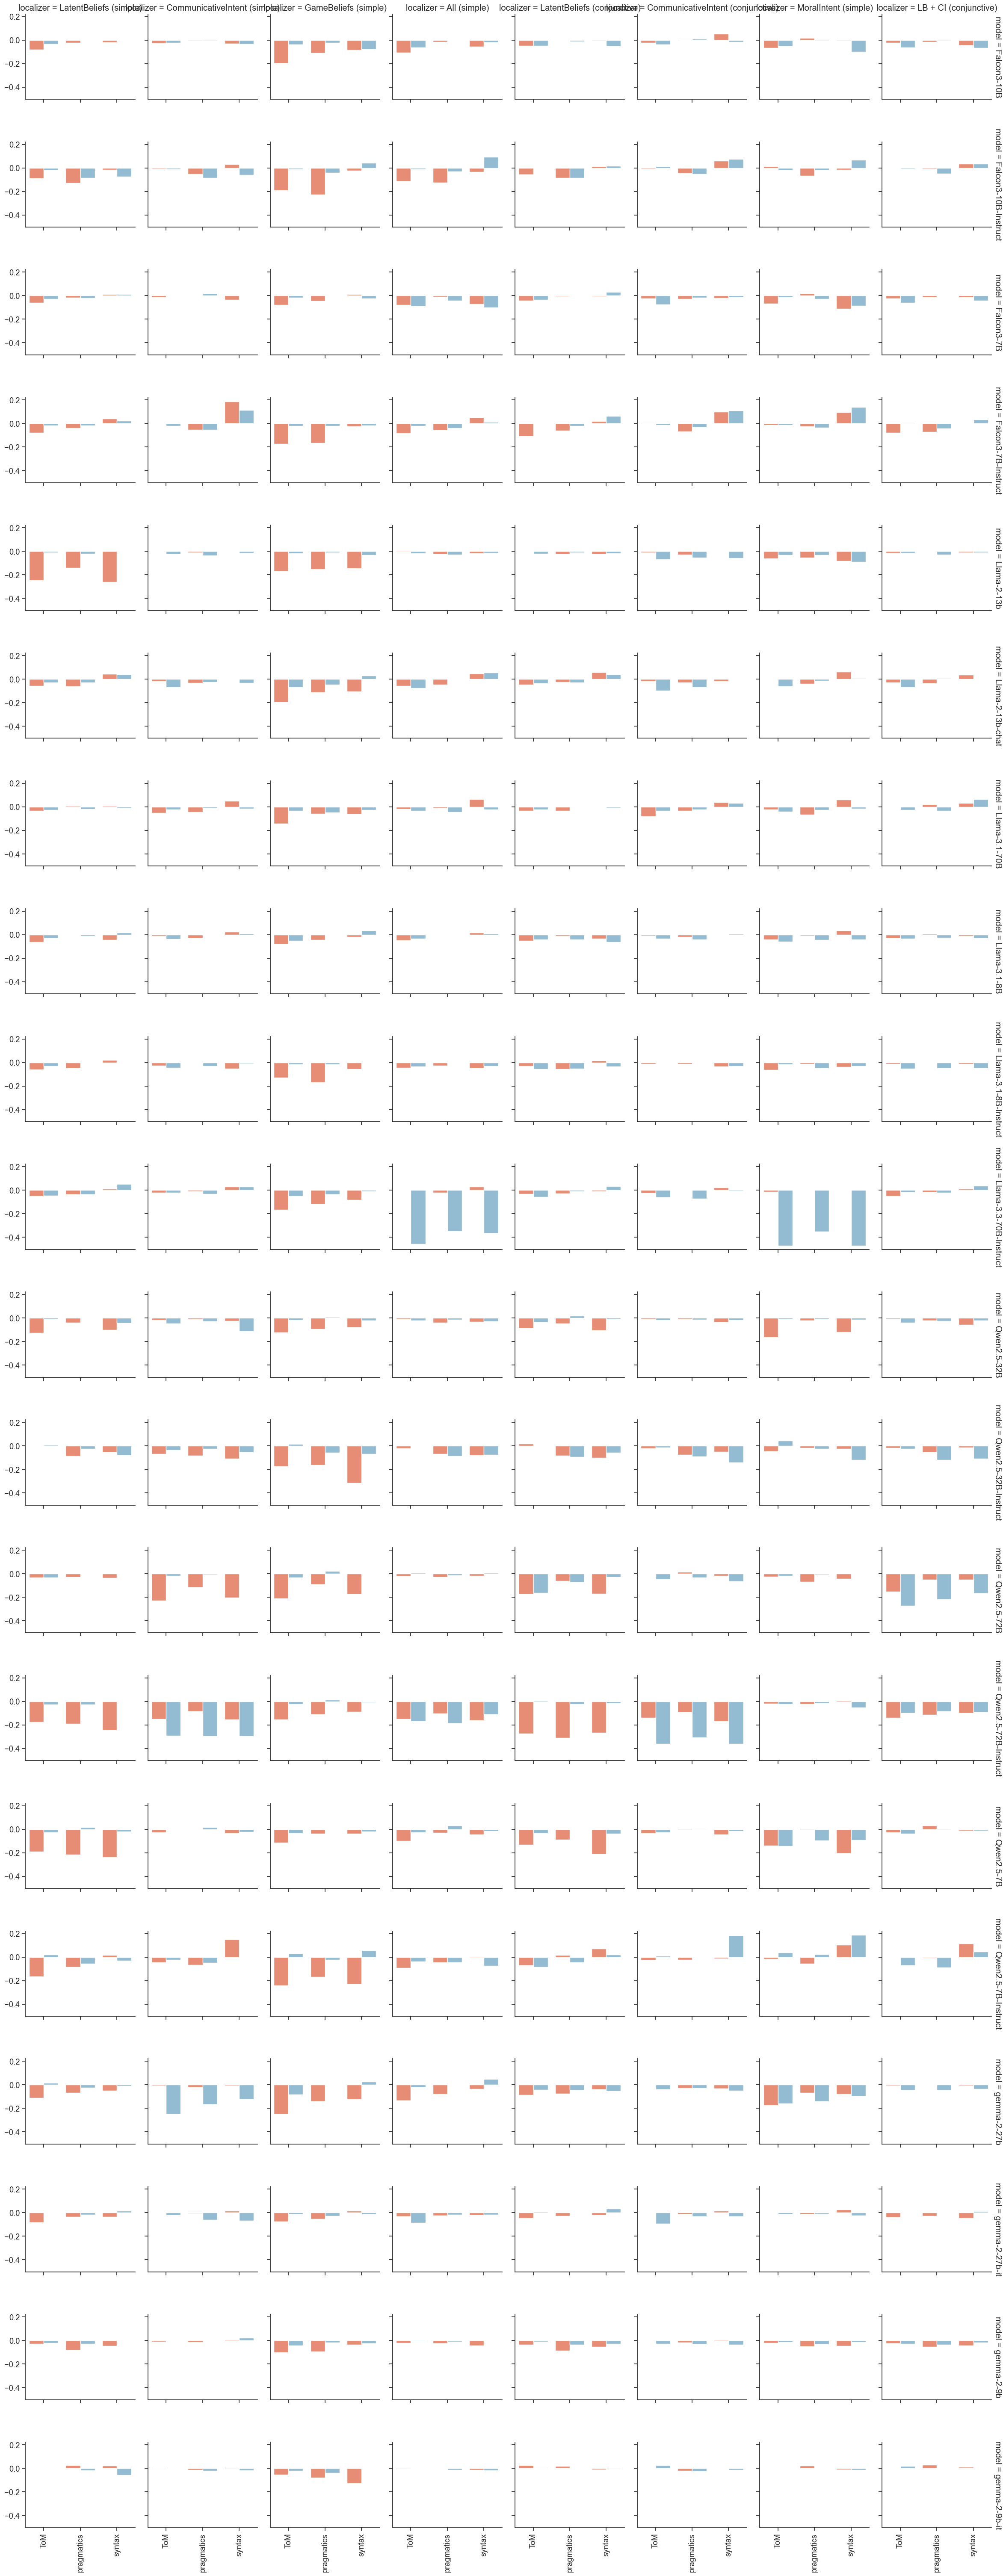

In [91]:
g_ablations = sns.FacetGrid(
    aligned_results_across_datasets,
    col="localizer",
    row="model",
    # hue="model_name",
    # hue_order=list(MODEL_SELECTED.keys()),
    # row_order=["theory-of-mind", "theory-of-mind-conjunctive", "random", "random-conjunctive"],
    # palette=MODEL_SELECTED,
    # col_wrap=4,
    height=3,
    aspect=1,
    legend_out=True,
    margin_titles=True,
)

g_ablations.map_dataframe(
    sns.barplot,
    y="delta_model_correct_mean",
    x="domain",
    hue="localizer_type",
    # col="model",
    # col_wrap=4,
    hue_order=["critical", "least active"],
    palette={
        "least active": blues[2],
        "critical": reds[2],
        # "syntax": greens[2],
    },
    dodge=True,
    errorbar=None,
    # height=3,
    # aspect=1,
    legend=True,
)
for ax in g_ablations.axes.flatten():
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("")
    ax.set_ylabel("")

Text(0.0, 0.5, 'Average change in accuracy after lesioning the subnetwork (across localizers)')

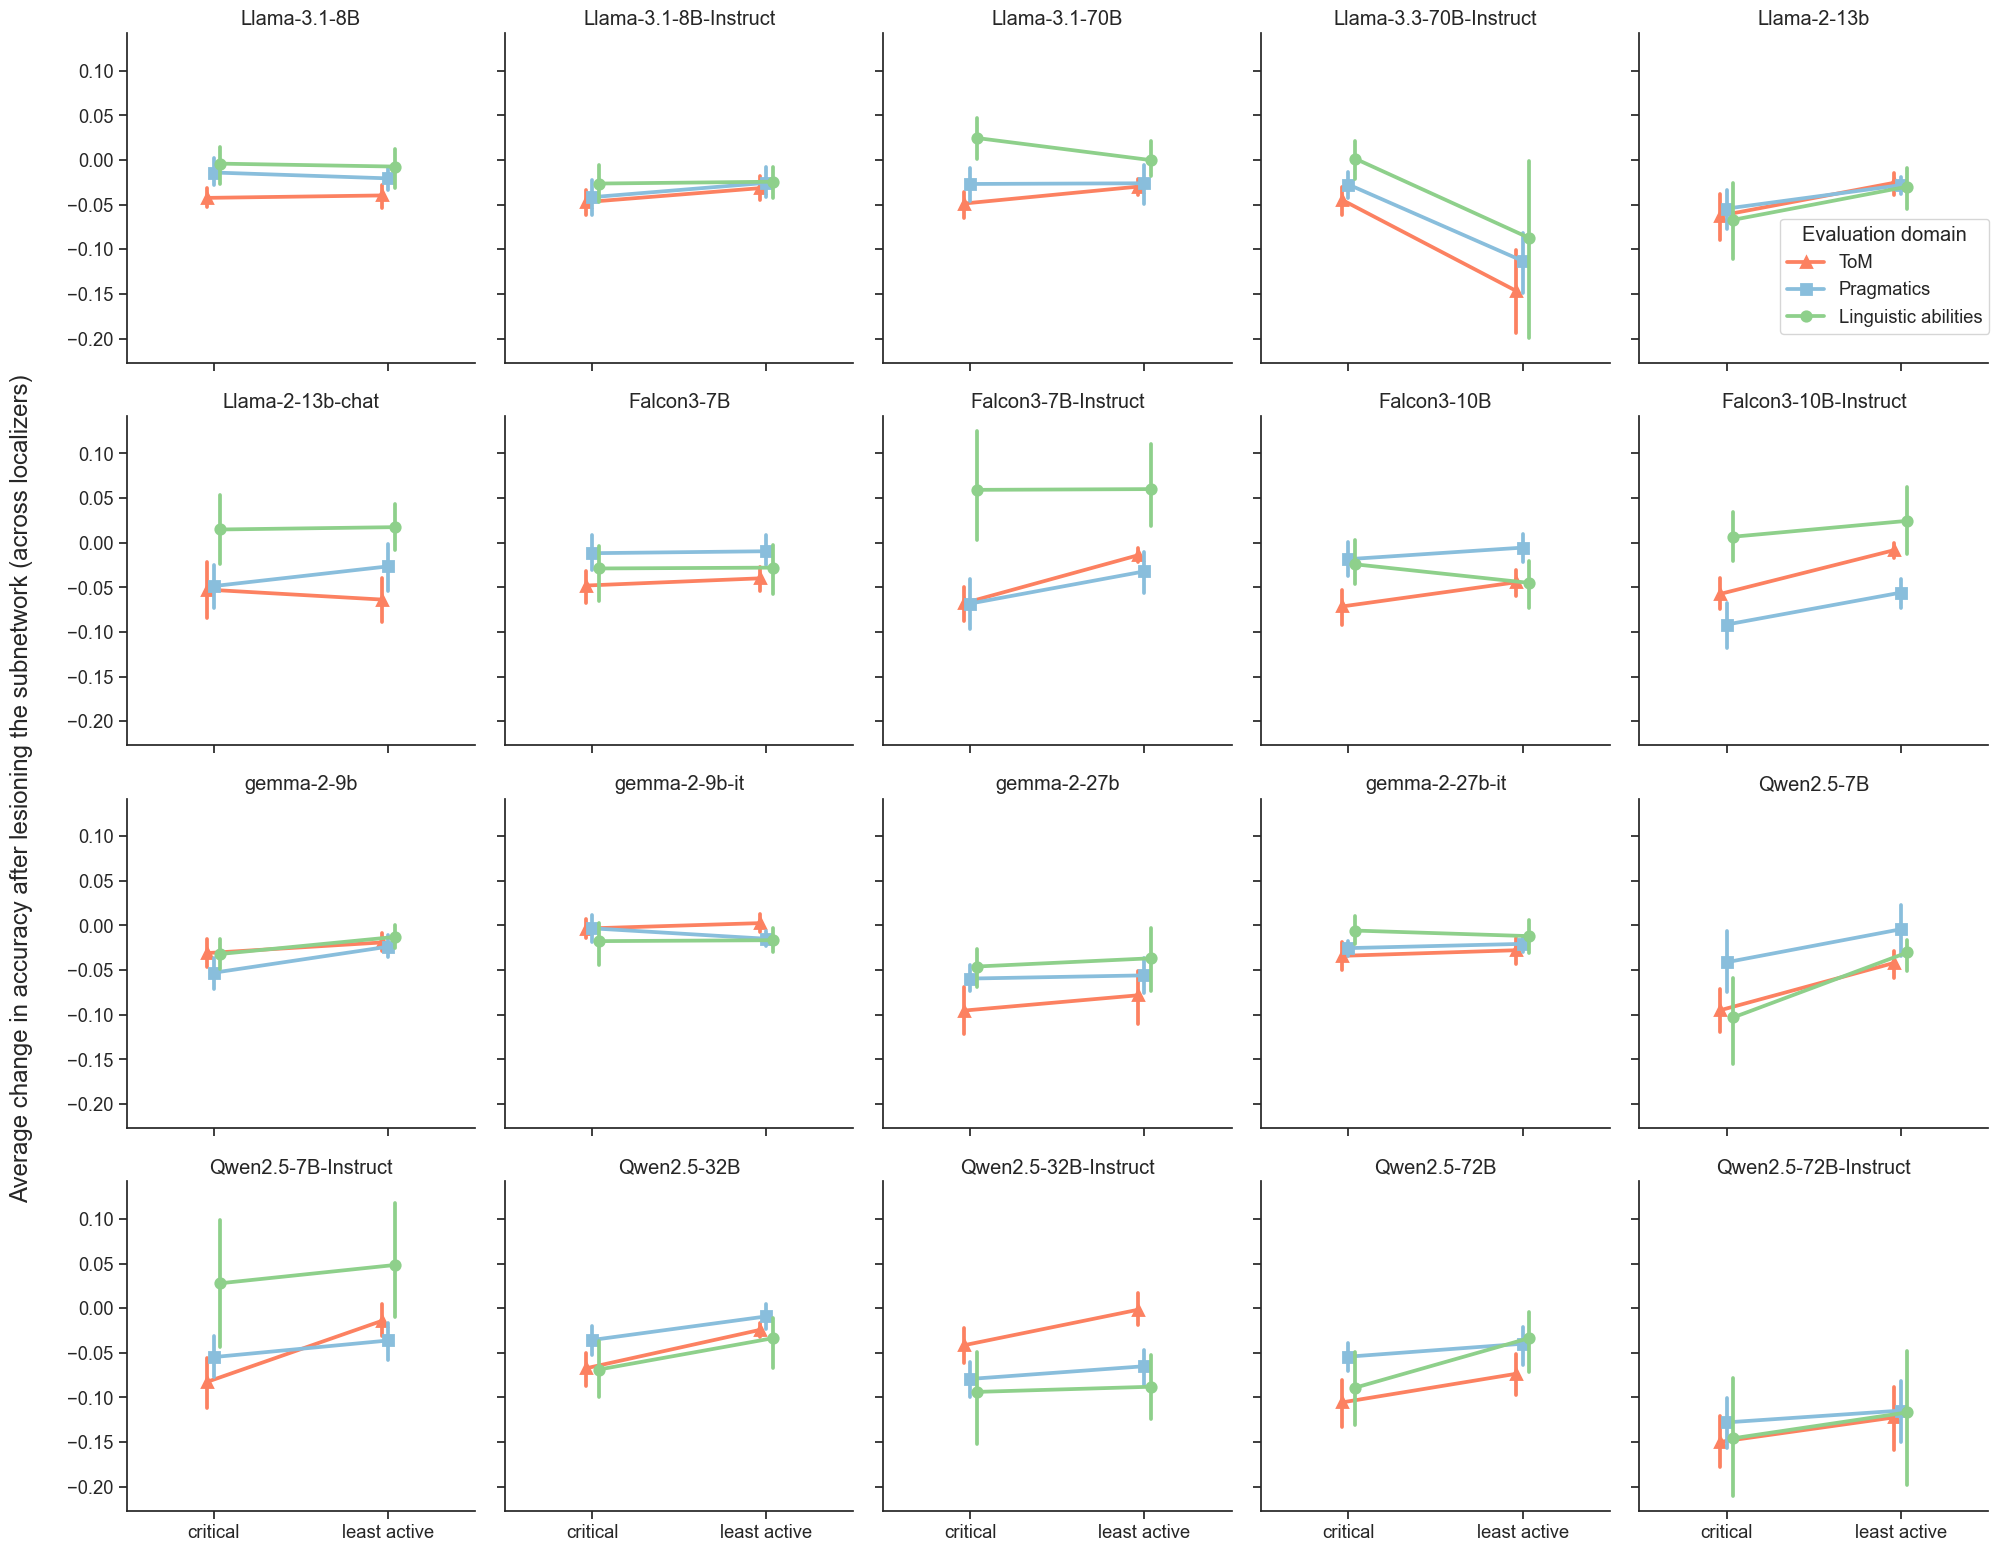

In [93]:
g = sns.catplot(
    data=aligned_results,
    kind="point",
    x="localizer_type",
    y="delta_model_correct_mean",
    hue="domain",
    palette={
        "Pragmatics": blues[2],
        "ToM": reds[2],
        "Linguistic abilities": greens[2],
    },
    col="model",
    col_order=list(MODEL_MAP.values()),
    col_wrap=5,
    hue_order=["ToM", "Pragmatics", "Linguistic abilities"],
    markers=["^", "s", "o"],
    dodge=True,
    errorbar=("ci", 95),
    height=4,
    aspect=1,
    legend=True,
    margin_titles=True,
)
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=0)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # ax.set_ylabel("Average change in accuracy after lesioning the subnetwork (across localizers)")

for ax, model_name in zip(g.axes.flat, g.col_names):
    ax.set_title(f"{model_name}")

# handles, labels = g.get_legend_handles_labels()
# print(labels)
# label_map = {
#     "pragmatics": "Pragmatics",
#     "tom": "ToM",
#     "syntax": "Linguistic abilities"
# }

# new_labels = [label_map.get(l, l) for l in labels]

sns.move_legend(
    g,
    "center right",
    bbox_to_anchor=(0.9, 0.82),  # (x, y) offset relative to axes
    frameon=True,
    title="Evaluation domain"
)
# shared y-axis label
g.fig.supylabel(
    "Average change in accuracy after lesioning the subnetwork (across localizers)",
    x=0.00  # tweak if needed
)

Text(0.0, 0.5, 'Average change in accuracy after lesioning')

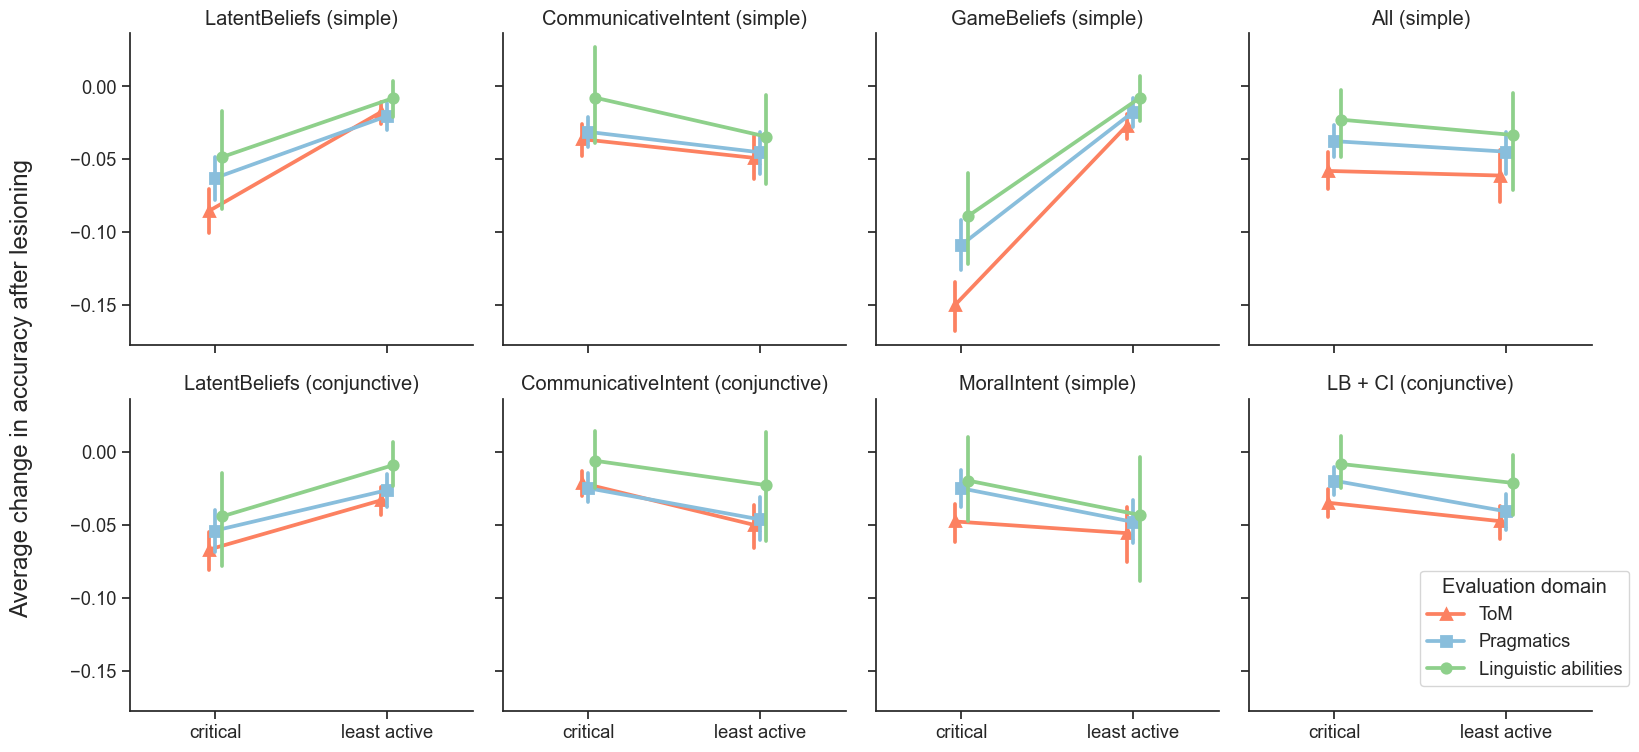

In [94]:
g = sns.catplot(
    data=aligned_results,
    kind="point",
    x="localizer_type",
    y="delta_model_correct_mean",
    hue="domain",
    palette={
        "Pragmatics": blues[2],
        "ToM": reds[2],
        "Linguistic abilities": greens[2],
    },
    col="localizer",
    col_wrap=4,
    hue_order=["ToM", "Pragmatics", "Linguistic abilities"],
    markers=["^", "s", "o"],
    dodge=True,
    errorbar=("ci", 95),
    height=4,
    aspect=1,
    legend=True,
)
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=0)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax, loc_name in zip(g.axes.flat, g.col_names):
    ax.set_title(f"{loc_name}")
    # ax.set_ylabel("Average change in accuracy after lesioning the subnetwork (across localizers)")
sns.move_legend(
    g,
    "center right",
    bbox_to_anchor=(0.9, 0.2),  # (x, y) offset relative to axes
    frameon=True,
    title="Evaluation domain"
)
# shared y-axis label
g.fig.supylabel(
    "Average change in accuracy after lesioning",
    x=0.00  # tweak if needed
)

In [ ]:
g_byDataset = sns.FacetGrid(
    aligned_results,
    col="localizer",
    row="model",
    # hue="model_name",
    # hue_order=list(MODEL_SELECTED.keys()),
    # row_order=["theory-of-mind", "theory-of-mind-conjunctive", "random", "random-conjunctive"],
    # palette=MODEL_SELECTED,
    # col_wrap=4,
    height=3,
    aspect=3,
    legend_out=True,
    margin_titles=True,
)

g_byDataset.map_dataframe(
    sns.barplot,
    y="delta_model_correct_mean",
    x="dataset",
    hue="localizer_type",
    # col="model",
    # col_wrap=4,
    hue_order=["critical", "least active"],
    palette={
        "least active": blues[2],
        "critical": reds[2],
        # "syntax": greens[2],
    },
    dodge=True,
    errorbar=None,
    # height=3,
    # aspect=1,
    legend=True,
)
for ax in g_byDataset.axes.flatten():
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("")
    ax.set_ylabel("")

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

# Factor levels (match your plot)
localizer_types = ["ToM", "pragmatics", "syntax"]
domains = ["critical", "least active"]

n_per_cell = 20

rows = []
for loc in localizer_types:
    for dom in domains:
        mean = {
            "critical": -0.15, 
            "least active": -0.05
           
        }[dom]

        # small systematic localizer shift
        mean += { 
            "ToM": -0.05,
            "pragmatics": -0.03,
            "syntax": -0.02  if dom == "least active" else + 0.06
        }[loc]

        values = np.random.normal(mean, 0.015, size=n_per_cell)

        for v in values:
            rows.append(
                dict(
                    localizer_type=loc,
                    domain=dom,
                    delta_model_correct_mean=v,
                    model="ExampleModel",
                )
            )

single_facet_data = pd.DataFrame(rows)


In [65]:
single_facet_data

,localizer_type,domain,delta_model_correct_mean,model
0,ToM,critical,-0.192549,ExampleModel
1,ToM,critical,-0.202074,ExampleModel
2,ToM,critical,-0.190285,ExampleModel
3,ToM,critical,-0.177155,ExampleModel
4,ToM,critical,-0.203512,ExampleModel
...,...,...,...,...
115,syntax,least active,-0.065477,ExampleModel
116,syntax,least active,-0.070521,ExampleModel
117,syntax,least active,-0.087530,ExampleModel
118,syntax,least active,-0.052858,ExampleModel


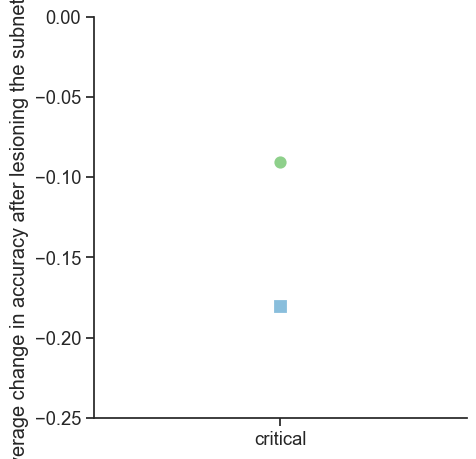

In [66]:
palette = {
    "pragmatics": blues[2],
    "ToM": reds[2],
    "syntax": greens[2],
}

sns.set(style="ticks", font_scale=1.2)

g = sns.catplot(
    data=single_facet_data[((single_facet_data["localizer_type"] == "pragmatics") & (single_facet_data["domain"] == "critical")) | ((single_facet_data["localizer_type"] == "syntax") & (single_facet_data["domain"] == "critical"))],
    kind="point",
    x="domain",
    y="delta_model_correct_mean",
    hue="localizer_type",
    hue_order=["ToM", "pragmatics", "syntax"],
    palette=palette,
    # style="localizer_type",
    markers=["^", "s", "o"],
    # dodge=True,
    errorbar=None, #("ci", 95),
    height=5,
    aspect=1,
    legend=False
)

# Axis cleanup (mirrors your loop)
ax = g.ax
# ax.set_title("Expected pattern under\nfunctional integration hypothesis")
ax.set_xlabel("")
ax.set_ylabel("Average change in accuracy after lesioning the subnetwork")
ax.set_ylim(-0.25, 0.00)

# Legend on top, horizontal
# sns.move_legend(
#     g,
#     loc="upper center",
#     bbox_to_anchor=(0.5, 1.15),
#     ncol=3,
#     frameon=True,
#     title="Evaluation domain",
# )

plt.show()


Text(0.0, 0.5, '')

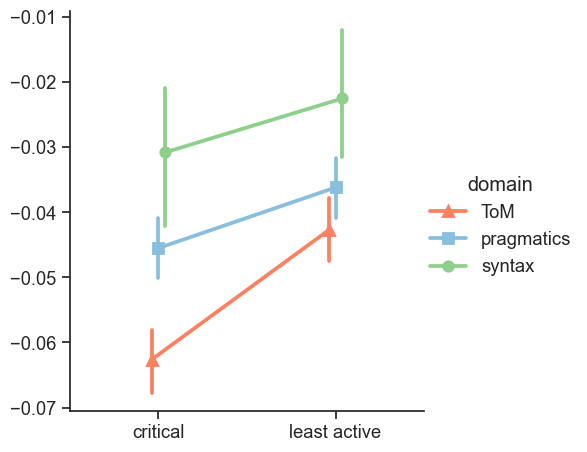

In [76]:
palette = {
    "pragmatics": blues[2],
    "ToM": reds[2],
    "syntax": greens[2],
}

sns.set(style="ticks", font_scale=1.2)

g_grandMean = sns.catplot(
    data=aligned_results,
    kind="point",
    x="localizer_type",
    y="delta_model_correct_mean",
    hue="domain",
    palette={
        "pragmatics": blues[2],
        "ToM": reds[2],
        "syntax": greens[2],
    },
    hue_order=["ToM", "pragmatics", "syntax"],
    markers=["^", "s", "o"],
    dodge=True,
    errorbar=("ci", 95),
    height=5,
    aspect=1,
    legend=True,
)
for ax in g_grandMean.axes.flatten():
    ax.tick_params(axis="x", rotation=0)
    # g_grandMean.set_xticklabels(["critical", "least active"], rotation=0, fontsize=18)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # ax.set_ylim(-0.25, 0.00)
# for ax, loc_name in zip(g_grandMean.axes.flat, g_grandMean.col_names):
#     ax.set_title(f"{loc_name}")
    # ax.set_ylabel("Average change in accuracy after lesioning the subnetwork (across localizers)")
# sns.move_legend(
#     g_grandMean,
#     "center right",
#     bbox_to_anchor=(1.1, 0.5),  # (x, y) offset relative to axes
#     frameon=True,
#     title="Evaluation domain"
# )
# shared y-axis label
g_grandMean.fig.supylabel(
    "",
    x=0.00  # tweak if needed
)

## Cache baseline ablation results

In [ ]:

def aggregate_over_lesioned_items_baseline(df, id_col="qid"):
    df_aggregated = df.groupby(["localizer_dataset", "localizer_type", "localization_procedure", "model", id_col]).apply(
        lambda r: 
        pd.DataFrame({
            "model_correct_mean_logprob": r["model_correct_mean_logprob"].all(),
            # "correct_lesion_sum_logprob": r["model_correct_sum_logprob"].all()
        }, index=[0])                                                
    ).reset_index()[["localizer_dataset", "localizer_type", "localization_procedure", "model", id_col, "model_correct_mean_logprob"]]

    return df_aggregated

def read_lesion_data_baseline(data_dir="../lesion_test_output/cache_baseline", datasets=DATASETS, MODELS_LESIONS = list(MODEL_MAP.values())):
    results = {}
    localizers = os.listdir(data_dir)
    for localizer in localizers:
        print("Found localizer:", localizer)
        localizer_dataset = localizer.split("|")[0]
        localizer_type = "random" if "random" in localizer.split("|")[1] else "theory-of-mind"
        localization_procedure = "conjunctive" if "conjunctive" in localizer.split("|")[1] else "simple"
        dfs_localizer = []
        for dataset in datasets:
            print("loading dataset:", dataset)
            cur_dir = Path(data_dir, localizer, dataset)
            if not cur_dir.exists():
                print(f"No data found ({cur_dir}); skipping...")
                continue
            dfs = []
            for f in listdir(Path(cur_dir)):
                if not any([m in f for m in list(MODELS_LESIONS)]):
                    print(f"Uknown model in {f}")
                    continue
                try:
                    d = pd.read_csv(Path(cur_dir, f))
                except Exception as e:
                    print(f"Could not read {f} due to {e}; skipping...")
                    continue
                d["localizer_dataset"]= localizer_dataset
                d["localizer_type"]= localizer_type
                d["localization_procedure"]= localization_procedure
                d["model"] = f.split("_network")[0]
                # print("----- model type ", model_type)

                dfs.append(d)
            df = pd.concat(dfs).reset_index()
            
            # handle datasets in long format, which need grouping by item ID
            # only correct prediction if all item-level pairwise predictions are correct (therefore, these tasks have a lower chance level performance)
            # these datasets are: opentom_attitude, pub_indirectness_interpretation, social_iqa, imppres_presupposition, imppres_implicature

            
            if (dataset == "opentom_attitude") or (dataset == "social_iqa") or (dataset.startswith("imppres")): 
                df[f"model_correct_mean_logprob"] = (
                        (df[f"correct_lesion_mean_logprob"].astype(float) > df[f"incorrect_lesion_mean_logprob"].astype(float)) 
                    )
                df = aggregate_over_lesioned_items(df, id_col="id")
                df["chance"] = 1/3 
            # elif (dataset == "pub_indirectness_interpretation"): 
            #     df = aggregate_over_items(df, id_col="pretext")
            #     df["chance"] = 0.25 (in the corrected version: 1/6?)
            
            elif (dataset == "emobench_understanding_emotion"):
                df[f"model_correct_mean_logprob"] = (
                    (df[f"correct_lesion_mean_logprob"].astype(float) > df[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                df = aggregate_over_lesioned_items(df, id_col="qid")
                df["chance"] = 1/6 


            elif (dataset.startswith("emobench")):
                df[f"model_correct_mean_logprob"] = (
                    (df[f"correct_lesion_mean_logprob"].astype(float) > df[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                df = aggregate_over_lesioned_items(df, id_col="qid")
                df["chance"] = 1/5

            # Process datasets with 2x2 scoring.
            elif dataset.startswith("ewok"):
                for metric in ["mean_logprob"]:
                    if f"context1_correct_lesion_{metric}" in df.columns:
                        df[f"model_correct_{metric}"] = (
                            (df[f"context1_correct_lesion_{metric}"].astype(float) > df[f"context2_incorrect_lesion_{metric}"].astype(float)) & \
                            (df[f"context2_correct_lesion_{metric}"].astype(float) > df[f"context1_incorrect_lesion_{metric}"].astype(float))
                        )
                    # See Section 4.1 of the EWOK paper about scoring criterion
                    else:
                        df[f"model_correct_{metric}"] = (
                            (df[f"Context1_correct_lesion_{metric}"].astype(float) > df[f"Context2_incorrect_lesion_{metric}"].astype(float)) & \
                            (df[f"Context2_correct_lesion_{metric}"].astype(float) > df[f"Context1_incorrect_lesion_{metric}"].astype(float))
                        )
                df["chance"] = 0.25
            elif dataset.startswith("tinytom") or dataset.startswith("bigtom") or dataset == "epitome_fb":
                for metric in ["mean_logprob"]:
                    df[f"model_correct_{metric}"] = (
                        (df[f"fb_correct_lesion_{metric}"].astype(float) > df[f"tb_incorrect_lesion_{metric}"].astype(float)) & \
                        (df[f"tb_correct_lesion_{metric}"].astype(float) > df[f"fb_incorrect_lesion_{metric}"].astype(float))
                    )
                df["chance"] = 0.25
            elif dataset.startswith("fauxpas"):
                # print(Path(cur_dir, f))
                # print(df.columns)
                # pivot to long format, so that q1_ and q4_ columns are separate rows and accuracy will be averaged across these two conditions
                fauxpas_q1 = df[[
                    "id", "type", "story", 'question_1', 'correct_1', 'incorrect_1', 'q1_correct_lesion_mean_logprob', 'q1_incorrect_lesion_mean_logprob',
                    'q1_correct_lesion_sum_logprob',
                    'q1_incorrect_lesion_sum_logprob',
                    'q1_scored_condition', "localizer_dataset", "localizer_type", "localization_procedure", "model"
                ]].rename({
                    'question_1': 'question', 
                    'correct_1': 'correct', 
                    'incorrect_1': 'incorrect', 
                    'q1_correct_lesion_mean_logprob': 'correct_lesion_mean_logprob', 
                    'q1_incorrect_lesion_mean_logprob': 'incorrect_lesion_mean_logprob',
                    'q1_correct_lesion_sum_logprob': 'correct_lesion_sum_logprob',
                    'q1_incorrect_lesion_sum_logprob': 'incorrect_lesion_sum_logprob', 
                    'q1_scored_condition': 'scored_condition'
                }, axis = 1)
                fauxpas_q1[f"model_correct_mean_logprob"] = (
                    (fauxpas_q1[f"correct_lesion_mean_logprob"].astype(float) > fauxpas_q1[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                fauxpas_q4 = df[[
                    "id", "type", "story", 'question_4', 'correct_4', 'incorrect_4', 'q4_correct_lesion_mean_logprob', 'q4_incorrect_lesion_mean_logprob',
                    'q4_correct_lesion_sum_logprob',
                    'q4_incorrect_lesion_sum_logprob',
                    'q4_scored_condition', "localizer_dataset", "localizer_type", "localization_procedure", "model"
                ]].rename({
                    'question_4': 'question', 
                    'correct_4': 'correct', 
                    'incorrect_4': 'incorrect', 
                    'q4_correct_lesion_mean_logprob': 'correct_lesion_mean_logprob', 
                    'q4_incorrect_lesion_mean_logprob': 'incorrect_lesion_mean_logprob',
                    'q4_correct_lesion_sum_logprob': 'correct_lesion_sum_logprob',
                    'q4_incorrect_lesion_sum_logprob': 'incorrect_lesion_sum_logprob', 
                    'q4_scored_condition': 'scored_condition'
                }, axis = 1)
                fauxpas_q4[f"model_correct_mean_logprob"] = (
                    (fauxpas_q4[f"correct_lesion_mean_logprob"].astype(float) > fauxpas_q4[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                df = pd.concat([fauxpas_q1, fauxpas_q4])
                df["chance"] = 0.5
            else:
                print("----- using means ------")
                df[f"model_correct_mean_logprob"] = (
                    (df[f"correct_lesion_mean_logprob"].astype(float) > df[f"incorrect_lesion_mean_logprob"].astype(float)) 
                )
                df["chance"] = 0.5
            
            # print(f"{dataset}: {len(df.index)} rows")

            df["dataset"] = dataset
            df["item_id"] = list(range(len(df)))
            dfs_localizer.append(df[["item_id", "localizer_dataset", "localizer_type", "localization_procedure", "model", "dataset", "chance", "model_correct_mean_logprob"]])
        
        loc_df = pd.concat(dfs_localizer).reset_index()
        results[localizer] = loc_df

    return results


In [ ]:
ablation_results_baseline = read_lesion_data(data_dir="../lesion_test_output/cache_baseline", datasets=DATASETS, MODELS_LESIONS = list(MODEL_MAP.values()))

### Rebuttal analyses

In [105]:
general_results = pd.read_csv("all_model_responses_tom_pragmatics_general.csv")
relevant_general_results = general_results[
    (general_results["model"].isin(list(MODEL_MAP.keys()))) & 
    (general_results["dataset"].isin(DATASETS))
]
relevant_blimp_results["domain"] = "Linguistic abilities" # relevant_blimp_results["dataset"] #
relevant_revision_results = pd.concat([
    relevant_general_results[["item_id", "model", "dataset", "chance", "model_correct_mean_logprob", "model_type", "domain", "model_correct"]], 
    relevant_blimp_results[["item_id", "model", "dataset", "chance", "model_correct_mean_logprob", "model_type", "domain", "model_correct"]]
])

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_50588/532175557.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  general_results = pd.read_csv("all_model_responses_tom_pragmatics_general.csv")
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_50588/532175557.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_blimp_results["domain"] = "Linguistic abilities" # relevant_blimp_results["dataset"] #


In [127]:
relevant_revision_results["model"] = relevant_revision_results["model"].map(MODEL_MAP)
relevant_revision_results["model"] = relevant_revision_results["model"].apply(lambda s: s.replace("Falcon3-10B-Base", "Falcon3-10B").replace("Falcon3-7B-Base", "Falcon3-7B").replace('Llama-2-13b-chat-hf', 'Llama-2-13b-chat').replace('Llama-2-13b-hf', 'Llama-2-13b'))

In [132]:
relevant_revision_results_summary = relevant_revision_results.groupby(["model", "dataset"]).aggregate({
    "model_correct": "mean",
}).reset_index()

relevant_revision_results_summary = relevant_revision_results_summary.rename({
    "model_correct": "baseline_model_correct"
}, axis=1)

In [133]:
ablation_results_summary_revisions = relevant_revision_results_summary.merge(ablation_results_summary, on=["model", "dataset"], suffixes=("_baseline", "_lesion"))

In [136]:
ablation_results_summary["model"].unique()
ablation_results_summary_revisions["dataset"].unique()

array(['bigtom_forward', 'blimp', 'emobench_application',
       'emobench_understanding_emotion', 'entity_tracking', 'epitome_rm',
       'ewok_agent-properties', 'ewok_social-interactions',
       'fauxpas_eai_q1_and_q4', 'hufloyd_deceits',
       'hufloyd_indirectspeech', 'hufloyd_irony', 'hufloyd_maxims',
       'hufloyd_metaphor', 'imppres_implicature',
       'imppres_presupposition', 'ludwig', 'opentom_attitude',
       'pub_agreement', 'pub_deictic_qa',
       'pub_indirectness_classification', 'pub_sarcasm', 'snli',
       'social_iqa', 'story_analogies', 'triangle-copa',
       'verbal_analogies', 'tomi_sapEtAl_first_order'], dtype=object)

In [131]:
relevant_revision_results["model"].unique()
ablation_results_summary

,localizer_dataset,localizer_type,localization_procedure,model,dataset,model_correct_mean_logprob
0,all,random,conjunctive,Falcon3-10B,bigtom_forward,0.447761
1,all,random,conjunctive,Falcon3-10B,blimp,0.786567
2,all,random,conjunctive,Falcon3-10B,emobench_application,0.560000
3,all,random,conjunctive,Falcon3-10B,emobench_understanding_emotion,0.275000
4,all,random,conjunctive,Falcon3-10B,entity_tracking,0.249254
...,...,...,...,...,...,...
8061,tom,theory-of-mind,simple,gemma-2-9b-it,pub_sarcasm,0.514000
8062,tom,theory-of-mind,simple,gemma-2-9b-it,snli,0.550746
8063,tom,theory-of-mind,simple,gemma-2-9b-it,social_iqa,0.502304
8064,tom,theory-of-mind,simple,gemma-2-9b-it,tomi_sapEtAl_first_order,0.750000


In [145]:
# check for which models the full set of results is available
ablation_results_summary_revisions[['model', 'localizer_type', "localizer_dataset",'localization_procedure', 'dataset']].drop_duplicates().value_counts('dataset')
# check for which models the full set of results is available
ablation_results_summary_revisions[['model', 'localizer_type', "localizer_dataset",'localization_procedure', 'dataset']].drop_duplicates().groupby(
    ['dataset']).value_counts(['model'])

dataset           model               
bigtom_forward    Falcon3-10B             16
                  Falcon3-10B-Instruct    16
                  Falcon3-7B              16
                  Falcon3-7B-Instruct     16
                  Llama-2-13b             16
                                          ..
verbal_analogies  Qwen2.5-72B             16
                  Qwen2.5-7B              16
                  Qwen2.5-7B-Instruct     16
                  Qwen2.5-72B-Instruct     2
                  gemma-2-27b-it           1
Name: count, Length: 509, dtype: int64

In [147]:
ablation_results_summary_revisions_newDS = ablation_results_summary_revisions[ablation_results_summary_revisions['dataset'].isin(['verbal_analogies', 'story_analogies', 'entity_tracking'])]

In [153]:
small_selected_models_df = ablation_results_summary_revisions_newDS.value_counts(["model"]).reset_index()
small_selected_models_df = small_selected_models_df[small_selected_models_df['count'] == 48]

In [ ]:
# look at performance of the five models on tom, prag, snli, story_analogies, verbal_analogies, entity_tracking
# ablation_results_summary_revisions = aligned_results.copy() #ablation_results_summary.copy()
# ablation_results_summary_revisions["domain"] = ablation_results_summary_revisions["dataset"].map(dataset_domains)

revisions_dataset = ablation_results_summary_revisions[ablation_results_summary_revisions['model'].isin(small_selected_models_df['model'].tolist())]

14


In [161]:
len(revisions_dataset)
dataset_domains_revisions = {
    'bigtom_forward': "ToM", 
    'emobench_application': "ToM",
    'emobench_understanding_emotion': "ToM", 
    'epitome_rm': "ToM",
    'ewok_agent-properties': "ToM", 
    'ewok_social-interactions': "ToM",
    'fauxpas_eai_q1_and_q4': "ToM", 
    'hufloyd_deceits': "Pragmatics",
    'hufloyd_indirectspeech': "Pragmatics", 
    'hufloyd_irony': "Pragmatics", 
    'hufloyd_maxims': "Pragmatics",
    'hufloyd_metaphor': "Pragmatics", 
    'imppres_implicature': "Pragmatics",
    'imppres_presupposition': "Pragmatics", 
    'ludwig': "Pragmatics", 
    'opentom_attitude': "ToM",
    'pub_agreement': "Pragmatics", 
    'pub_deictic_qa': "Pragmatics",
    'pub_indirectness_classification': "Pragmatics", 
    'pub_sarcasm': "Pragmatics", 
    'social_iqa': "ToM",
    'triangle-copa': "ToM", 
    'tomi_sapEtAl_first_order': "Pragmatics",
    'blimp': "Linguistic abilities",
    'snli': "Linguistic abilities",
    'story_analogies': "General reasoning",
    'verbal_analogies': "General reasoning",
    'entity_tracking': "General reasoning"
}


revisions_dataset['dataset'].unique()

array(['bigtom_forward', 'blimp', 'emobench_application',
       'emobench_understanding_emotion', 'entity_tracking', 'epitome_rm',
       'ewok_agent-properties', 'ewok_social-interactions',
       'fauxpas_eai_q1_and_q4', 'hufloyd_deceits',
       'hufloyd_indirectspeech', 'hufloyd_irony', 'hufloyd_maxims',
       'hufloyd_metaphor', 'imppres_implicature',
       'imppres_presupposition', 'ludwig', 'opentom_attitude',
       'pub_agreement', 'pub_deictic_qa',
       'pub_indirectness_classification', 'pub_sarcasm', 'snli',
       'social_iqa', 'story_analogies', 'triangle-copa',
       'verbal_analogies', 'tomi_sapEtAl_first_order'], dtype=object)

In [162]:
revisions_dataset["domain"] = revisions_dataset['dataset'].map(dataset_domains_revisions)
revisions_dataset['domain'].unique()

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_50588/91337411.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  revisions_dataset["domain"] = revisions_dataset['dataset'].map(dataset_domains_revisions)


array(['ToM', 'Linguistic abilities', 'General reasoning', 'Pragmatics'],
      dtype=object)

In [163]:
revisions_dataset["localizer"] = revisions_dataset["localizer_dataset"] + "_" + revisions_dataset["localization_procedure"] 
revisions_dataset["localizer"] = pd.Categorical(revisions_dataset["localizer"], categories=[
    "tom_simple", "deceptive_communication_simple", "strategic_games_simple", "all_simple",
    "tom_conjunctive", "deceptive_communication_conjunctive","moral_intent_simple" , "all_conjunctive"]
)
revisions_dataset["localizer"] = revisions_dataset["localizer"].cat.rename_categories({
    "tom_simple": "LatentBeliefs (simple)", 
    "deceptive_communication_simple": "CommunicativeIntent (simple)", 
    "strategic_games_simple": "GameBeliefs (simple)", 
    "all_simple": "All (simple)",
    "tom_conjunctive": "LatentBeliefs (conjunctive)", 
    "deceptive_communication_conjunctive": "CommunicativeIntent (conjunctive)",
    "moral_intent_simple": "MoralIntent (simple)",
    "all_conjunctive": "LB + CI (conjunctive)"
})

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_50588/828140456.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  revisions_dataset["localizer"] = revisions_dataset["localizer_dataset"] + "_" + revisions_dataset["localization_procedure"]
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_50588/828140456.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  revisions_dataset["localizer"] = pd.Categorical(revisions_dataset["localizer"], categories=[
/var/folders/fn/6ct_6l112376k8288ws7798m0

In [164]:
revisions_dataset["localizer_type"] = revisions_dataset["localizer_type"].apply(lambda s: "critical" if s == "theory-of-mind" else s)
revisions_dataset["localizer_type"] = revisions_dataset["localizer_type"].apply(lambda s: "least active" if s == "random" else s)
revisions_dataset["localizer_type"] = pd.Categorical(revisions_dataset["localizer_type"], categories=['critical', 'least active'])

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_50588/647870958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  revisions_dataset["localizer_type"] = revisions_dataset["localizer_type"].apply(lambda s: "critical" if s == "theory-of-mind" else s)
/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_50588/647870958.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  revisions_dataset["localizer_type"] = revisions_dataset["localizer_type"].apply(lambda s: "least active" if s == "random" el

In [165]:
revisions_dataset["model_type"] = revisions_dataset["model"].apply(lambda s: "instruct" if ("instruct" in s.lower()) or ("-it" in s.lower()) or ("chat" in s.lower()) else "base") 
revisions_dataset

/var/folders/fn/6ct_6l112376k8288ws7798m0000gn/T/ipykernel_50588/2909468326.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  revisions_dataset["model_type"] = revisions_dataset["model"].apply(lambda s: "instruct" if ("instruct" in s.lower()) or ("-it" in s.lower()) or ("chat" in s.lower()) else "base")


,model,dataset,baseline_model_correct,localizer_dataset,localizer_type,localization_procedure,model_correct_mean_logprob,domain,localizer,model_type
0,Falcon3-10B,bigtom_forward,0.646766,all,least active,conjunctive,0.447761,ToM,LB + CI (conjunctive),base
1,Falcon3-10B,bigtom_forward,0.646766,all,least active,simple,0.457711,ToM,All (simple),base
2,Falcon3-10B,bigtom_forward,0.646766,all,critical,conjunctive,0.562189,ToM,LB + CI (conjunctive),base
3,Falcon3-10B,bigtom_forward,0.646766,all,critical,simple,0.333333,ToM,All (simple),base
4,Falcon3-10B,bigtom_forward,0.646766,deceptive_communication,least active,conjunctive,0.527363,ToM,CommunicativeIntent (conjunctive),base
...,...,...,...,...,...,...,...,...,...,...
6461,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,strategic_games,critical,simple,0.462500,General reasoning,GameBeliefs (simple),instruct
6462,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,least active,conjunctive,0.550000,General reasoning,LatentBeliefs (conjunctive),instruct
6463,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,least active,simple,0.650000,General reasoning,LatentBeliefs (simple),instruct
6464,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,critical,conjunctive,0.662500,General reasoning,LatentBeliefs (conjunctive),instruct


In [ ]:
# select the localizers we are actually interested in
# selected_localizers = ["LatentBeliefs (simple)", "GameBeliefs (simple)"]
# revisions_dataset = revisions_dataset[revisions_dataset["localizer"].isin(selected_localizers)]
# revisions_dataset

,model,dataset,baseline_model_correct,localizer_dataset,localizer_type,localization_procedure,model_correct_mean_logprob,domain,localizer,model_type
0,Falcon3-10B,bigtom_forward,0.646766,all,least active,conjunctive,0.447761,ToM,LB + CI (conjunctive),base
1,Falcon3-10B,bigtom_forward,0.646766,all,least active,simple,0.457711,ToM,All (simple),base
2,Falcon3-10B,bigtom_forward,0.646766,all,critical,conjunctive,0.562189,ToM,LB + CI (conjunctive),base
3,Falcon3-10B,bigtom_forward,0.646766,all,critical,simple,0.333333,ToM,All (simple),base
4,Falcon3-10B,bigtom_forward,0.646766,deceptive_communication,least active,conjunctive,0.527363,ToM,CommunicativeIntent (conjunctive),base
...,...,...,...,...,...,...,...,...,...,...
6461,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,strategic_games,critical,simple,0.462500,General reasoning,GameBeliefs (simple),instruct
6462,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,least active,conjunctive,0.550000,General reasoning,LatentBeliefs (conjunctive),instruct
6463,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,least active,simple,0.650000,General reasoning,LatentBeliefs (simple),instruct
6464,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,critical,conjunctive,0.662500,General reasoning,LatentBeliefs (conjunctive),instruct


In [166]:
revisions_dataset_clean = revisions_dataset.copy()
revisions_dataset_clean["localizer"] = revisions_dataset_clean["localizer"].cat.remove_unused_categories()
revisions_dataset_clean

,model,dataset,baseline_model_correct,localizer_dataset,localizer_type,localization_procedure,model_correct_mean_logprob,domain,localizer,model_type
0,Falcon3-10B,bigtom_forward,0.646766,all,least active,conjunctive,0.447761,ToM,LB + CI (conjunctive),base
1,Falcon3-10B,bigtom_forward,0.646766,all,least active,simple,0.457711,ToM,All (simple),base
2,Falcon3-10B,bigtom_forward,0.646766,all,critical,conjunctive,0.562189,ToM,LB + CI (conjunctive),base
3,Falcon3-10B,bigtom_forward,0.646766,all,critical,simple,0.333333,ToM,All (simple),base
4,Falcon3-10B,bigtom_forward,0.646766,deceptive_communication,least active,conjunctive,0.527363,ToM,CommunicativeIntent (conjunctive),base
...,...,...,...,...,...,...,...,...,...,...
6461,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,strategic_games,critical,simple,0.462500,General reasoning,GameBeliefs (simple),instruct
6462,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,least active,conjunctive,0.550000,General reasoning,LatentBeliefs (conjunctive),instruct
6463,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,least active,simple,0.650000,General reasoning,LatentBeliefs (simple),instruct
6464,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,critical,conjunctive,0.662500,General reasoning,LatentBeliefs (conjunctive),instruct


In [169]:
revisions_dataset_clean['delta_model_correct_mean'] = revisions_dataset_clean["model_correct_mean_logprob"] - revisions_dataset_clean["baseline_model_correct"] 

In [182]:
revisions_dataset_summary = revisions_dataset_clean #.groupby(["localizer_type", "model", "domain", "localizer"]).aggregate({
#     "model_correct_mean_logprob": "mean",
#     "delta_model_correct_mean": "mean"
# }).reset_index()
revisions_dataset_summary

,model,dataset,baseline_model_correct,localizer_dataset,localizer_type,localization_procedure,model_correct_mean_logprob,domain,localizer,model_type,delta_model_correct_mean
0,Falcon3-10B,bigtom_forward,0.646766,all,least active,conjunctive,0.447761,ToM,LB + CI (conjunctive),base,-0.199005
1,Falcon3-10B,bigtom_forward,0.646766,all,least active,simple,0.457711,ToM,All (simple),base,-0.189055
2,Falcon3-10B,bigtom_forward,0.646766,all,critical,conjunctive,0.562189,ToM,LB + CI (conjunctive),base,-0.084577
3,Falcon3-10B,bigtom_forward,0.646766,all,critical,simple,0.333333,ToM,All (simple),base,-0.313433
4,Falcon3-10B,bigtom_forward,0.646766,deceptive_communication,least active,conjunctive,0.527363,ToM,CommunicativeIntent (conjunctive),base,-0.119403
...,...,...,...,...,...,...,...,...,...,...,...
6461,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,strategic_games,critical,simple,0.462500,General reasoning,GameBeliefs (simple),instruct,-0.300000
6462,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,least active,conjunctive,0.550000,General reasoning,LatentBeliefs (conjunctive),instruct,-0.212500
6463,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,least active,simple,0.650000,General reasoning,LatentBeliefs (simple),instruct,-0.112500
6464,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,critical,conjunctive,0.662500,General reasoning,LatentBeliefs (conjunctive),instruct,-0.100000


In [183]:
revisions_dataset_summary_noNa = revisions_dataset_summary.dropna()
revisions_dataset_summary_noNa

,model,dataset,baseline_model_correct,localizer_dataset,localizer_type,localization_procedure,model_correct_mean_logprob,domain,localizer,model_type,delta_model_correct_mean
0,Falcon3-10B,bigtom_forward,0.646766,all,least active,conjunctive,0.447761,ToM,LB + CI (conjunctive),base,-0.199005
1,Falcon3-10B,bigtom_forward,0.646766,all,least active,simple,0.457711,ToM,All (simple),base,-0.189055
2,Falcon3-10B,bigtom_forward,0.646766,all,critical,conjunctive,0.562189,ToM,LB + CI (conjunctive),base,-0.084577
3,Falcon3-10B,bigtom_forward,0.646766,all,critical,simple,0.333333,ToM,All (simple),base,-0.313433
4,Falcon3-10B,bigtom_forward,0.646766,deceptive_communication,least active,conjunctive,0.527363,ToM,CommunicativeIntent (conjunctive),base,-0.119403
...,...,...,...,...,...,...,...,...,...,...,...
6461,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,strategic_games,critical,simple,0.462500,General reasoning,GameBeliefs (simple),instruct,-0.300000
6462,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,least active,conjunctive,0.550000,General reasoning,LatentBeliefs (conjunctive),instruct,-0.212500
6463,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,least active,simple,0.650000,General reasoning,LatentBeliefs (simple),instruct,-0.112500
6464,Qwen2.5-7B-Instruct,verbal_analogies,0.762500,tom,critical,conjunctive,0.662500,General reasoning,LatentBeliefs (conjunctive),instruct,-0.100000


In [184]:
revisions_dataset_summary_noNa["localizer"].unique()

['LB + CI (conjunctive)', 'All (simple)', 'CommunicativeIntent (conjunctive)', 'CommunicativeIntent (simple)', 'MoralIntent (simple)', 'GameBeliefs (simple)', 'LatentBeliefs (conjunctive)', 'LatentBeliefs (simple)']
Categories (8, object): ['LatentBeliefs (simple)', 'CommunicativeIntent (simple)', 'GameBeliefs (simple)', 'All (simple)', 'LatentBeliefs (conjunctive)', 'CommunicativeIntent (conjunctive)', 'MoralIntent (simple)', 'LB + CI (conjunctive)']

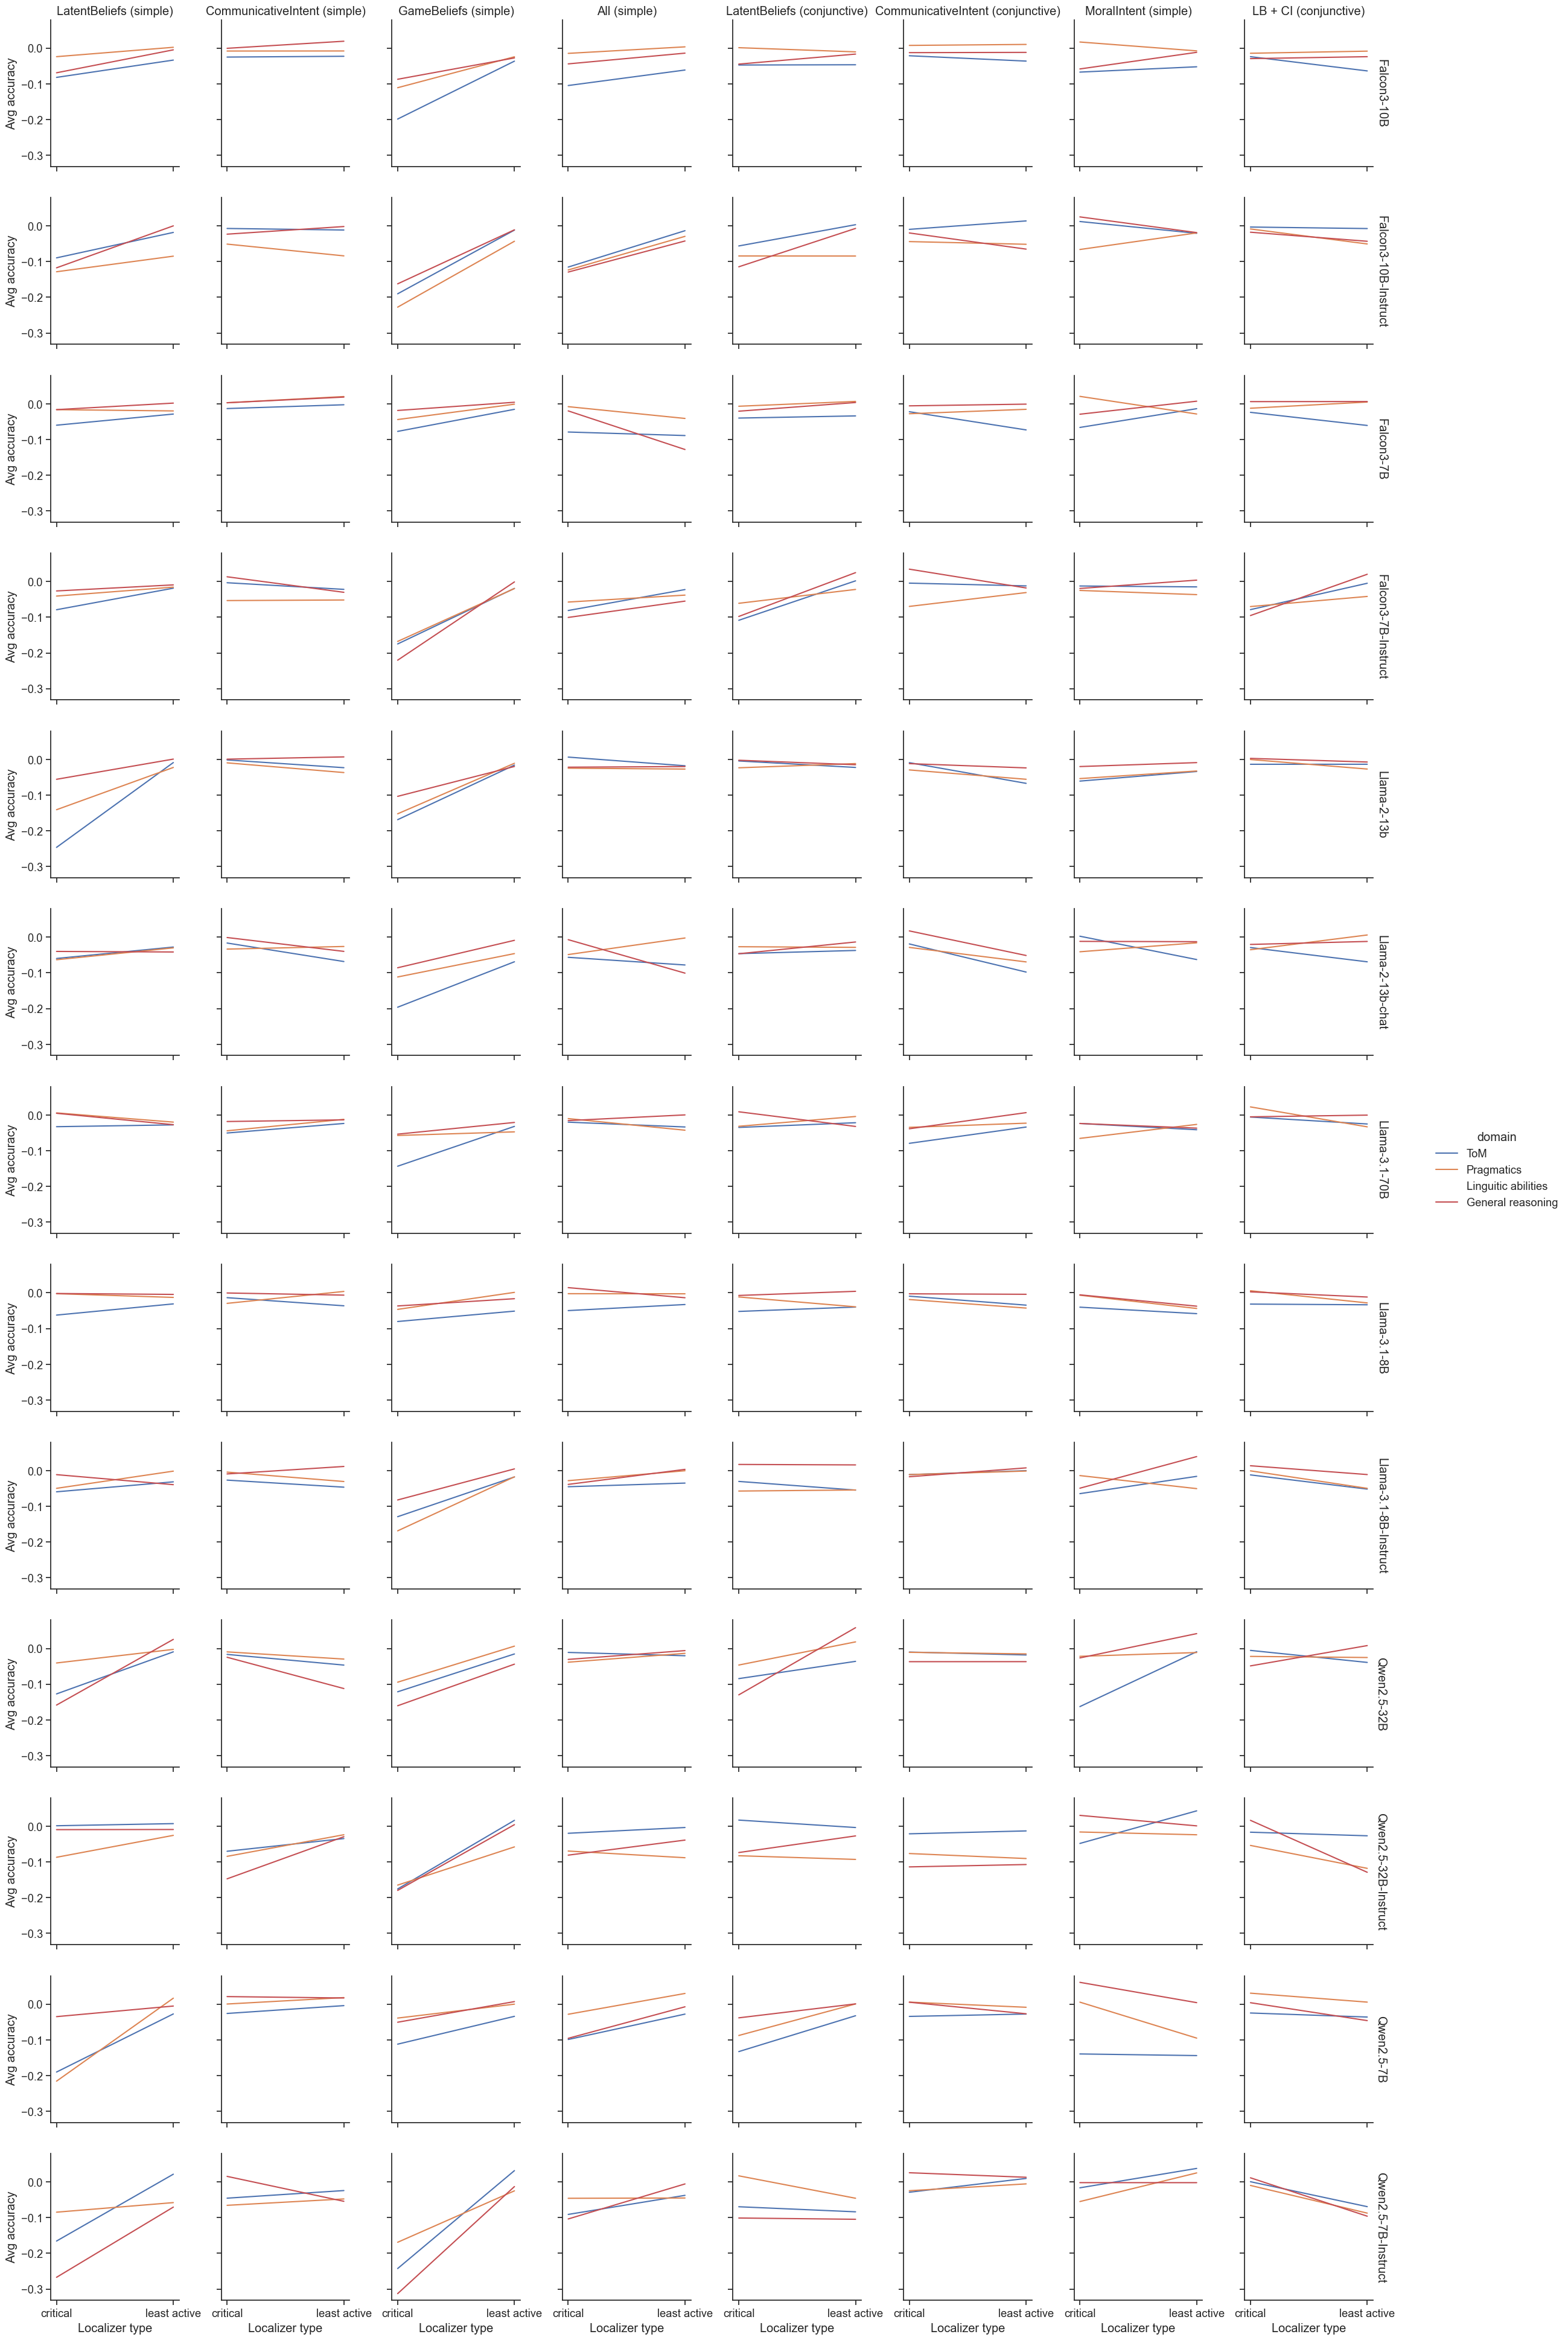

In [173]:
# grid plot by-model by-localizer, with localizer type on the x axis, color coding of the domain, and model_correct_mean_logprob on the y axis

import seaborn as sns
import matplotlib.pyplot as plt

# Define custom color palette
domain_colors = {
    "ToM": reds[2],
    "Pragmatics": blues[2],
    "Linguistic abilities": greens[2],
    "General reasoning": yellows[4],
    # "entity_tracking": greens[3], 
    # "story_analogies": greens[2],
    # "verbal_analogies": greens[1] 
}

g = sns.FacetGrid(revisions_dataset_summary_noNa, row="model", col="localizer", hue="domain", 
                   hue_order=["ToM", "Pragmatics", "Linguitic abilities", "General reasoning"], #  "snli", "entity_tracking", "story_analogies", "verbal_analogies"
                  margin_titles=True)
g.map_dataframe(sns.lineplot, x="localizer_type", y="delta_model_correct_mean")
g.add_legend()
g.set_axis_labels("Localizer type", "Avg accuracy")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.show()

In [181]:
revisions_dataset_summary_noNa

,localizer_type,model,domain,localizer,model_correct_mean_logprob,delta_model_correct_mean
0,critical,Falcon3-10B,General reasoning,LatentBeliefs (simple),0.406979,-0.069216
1,critical,Falcon3-10B,General reasoning,CommunicativeIntent (simple),0.475511,-0.000684
2,critical,Falcon3-10B,General reasoning,GameBeliefs (simple),0.388820,-0.087376
3,critical,Falcon3-10B,General reasoning,All (simple),0.431917,-0.044279
4,critical,Falcon3-10B,General reasoning,LatentBeliefs (conjunctive),0.431295,-0.044900
...,...,...,...,...,...,...
827,least active,Qwen2.5-7B-Instruct,ToM,All (simple),0.555897,-0.037638
828,least active,Qwen2.5-7B-Instruct,ToM,LatentBeliefs (conjunctive),0.509797,-0.083737
829,least active,Qwen2.5-7B-Instruct,ToM,CommunicativeIntent (conjunctive),0.603308,0.009774
830,least active,Qwen2.5-7B-Instruct,ToM,MoralIntent (simple),0.631303,0.037768


In [185]:
revisions_dataset_summary_noNa["detailed_domain"] = revisions_dataset_summary_noNa.apply(lambda s: s['domain'] if s["domain"] != "General reasoning" else s['dataset'], axis=1)

In [189]:
revisions_dataset_summary_noNa["detailed_domain"] = revisions_dataset_summary_noNa["detailed_domain"].replace("entity_tracking", "Entity tracking").replace("story_analogies", "Story analogies").replace("verbal_analogies", "Verbal analogies")
revisions_dataset_summary_noNa["detailed_domain"].unique()

array(['ToM', 'Linguistic abilities', 'Entity tracking', 'Pragmatics',
       'Story analogies', 'Verbal analogies'], dtype=object)

In [210]:
revisions_dataset_summary_noNa['model'].unique()

array(['Falcon3-10B', 'Falcon3-10B-Instruct', 'Falcon3-7B',
       'Falcon3-7B-Instruct', 'Llama-2-13b', 'Llama-2-13b-chat',
       'Llama-3.1-70B', 'Llama-3.1-8B', 'Llama-3.1-8B-Instruct',
       'Qwen2.5-32B', 'Qwen2.5-32B-Instruct', 'Qwen2.5-7B',
       'Qwen2.5-7B-Instruct'], dtype=object)

Text(0.02, 0.5, 'Average change in accuracy after lesioning')

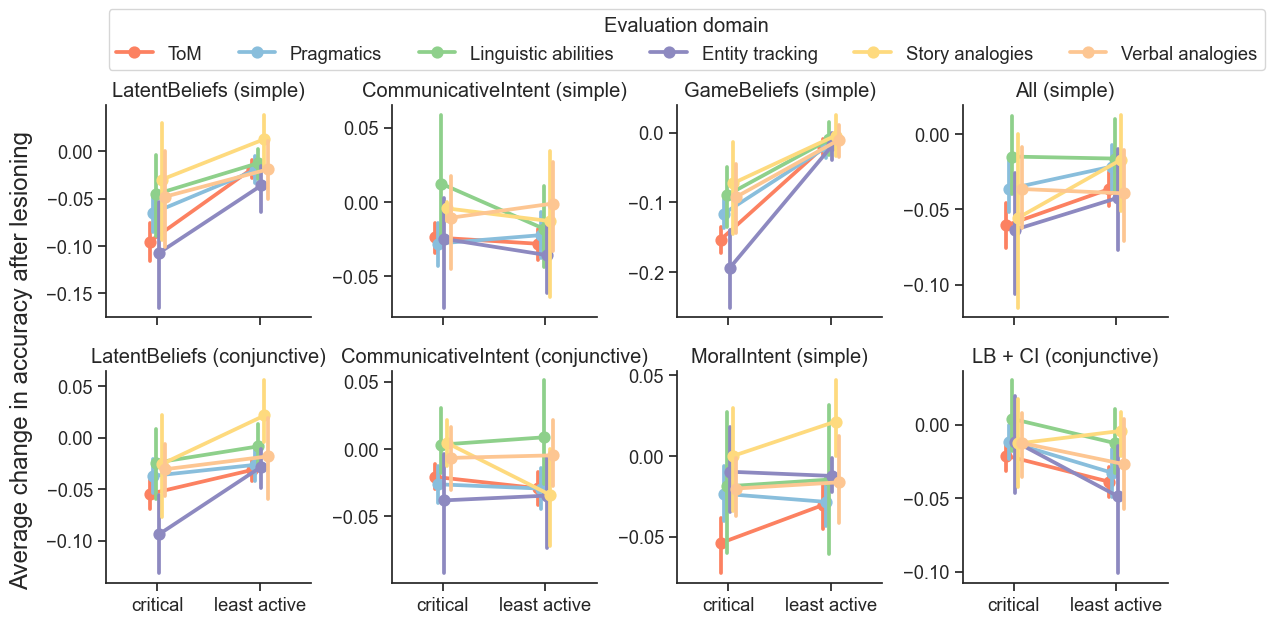

In [195]:
g_reb = sns.catplot(
    data=revisions_dataset_summary_noNa,
    kind="point",
    x="localizer_type",
    y="delta_model_correct_mean",
    hue="detailed_domain",
    col="localizer",
    # row="model",
    col_wrap=4,
    # row_order=list(MODEL_MAP.values())[10:],
    # col_order= ["LatentBeliefs (simple)", "LatentBeliefs (conjunctive)",  "CommunicativeIntent (simple)", "CommunicativeIntent (conjunctive)","GameBeliefs (simple)", "MoralIntent (simple)", "All (simple)","LB + CI (conjunctive)"],
    hue_order=["ToM", "Pragmatics", "Linguistic abilities", "Entity tracking", 'Story analogies', 'Verbal analogies'],
    # markers=["^", "s", "o"],
    palette={
        "Pragmatics": blues[2],
        "ToM": reds[2],
        "Linguistic abilities": greens[2],
        "Entity tracking": purples[3],
        "Story analogies": yellows[1],
        "Verbal analogies": oranges[1],
    },
    dodge=True,
    errorbar=("ci", 95),
    height=3,
    aspect=1,
    legend=True,
    margin_titles=True,
    sharey=False
)
for ax in g_reb.axes.flatten():
    # ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        # label.set_ha('right')
    # ax.set_ylabel("Average change in accuracy after lesioning the subnetwork (across localizers)")
g_reb.set_titles(col_template="{col_name}", row_template="{row_name}")

sns.move_legend(
    g_reb,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),   # centered above the grid
    ncol=len(g_reb._legend_data),     # horizontal layout
    frameon=True,
    title="Evaluation domain"
)
# shared y-axis label
g_reb.fig.supylabel(
    "Average change in accuracy after lesioning",
    x=0.02  # tweak if needed
)
# plt.tight_layout()
    

In [202]:
models_part1 = revisions_dataset_summary_noNa['model'].unique().tolist()[:6]
models_part2 = revisions_dataset_summary_noNa['model'].unique().tolist()[6:]
revisions_dataset_summary_noNa_part1 = revisions_dataset_summary_noNa[revisions_dataset_summary_noNa['model'].isin(models_part1)]
revisions_dataset_summary_noNa_part2 = revisions_dataset_summary_noNa[revisions_dataset_summary_noNa['model'].isin(models_part2)]


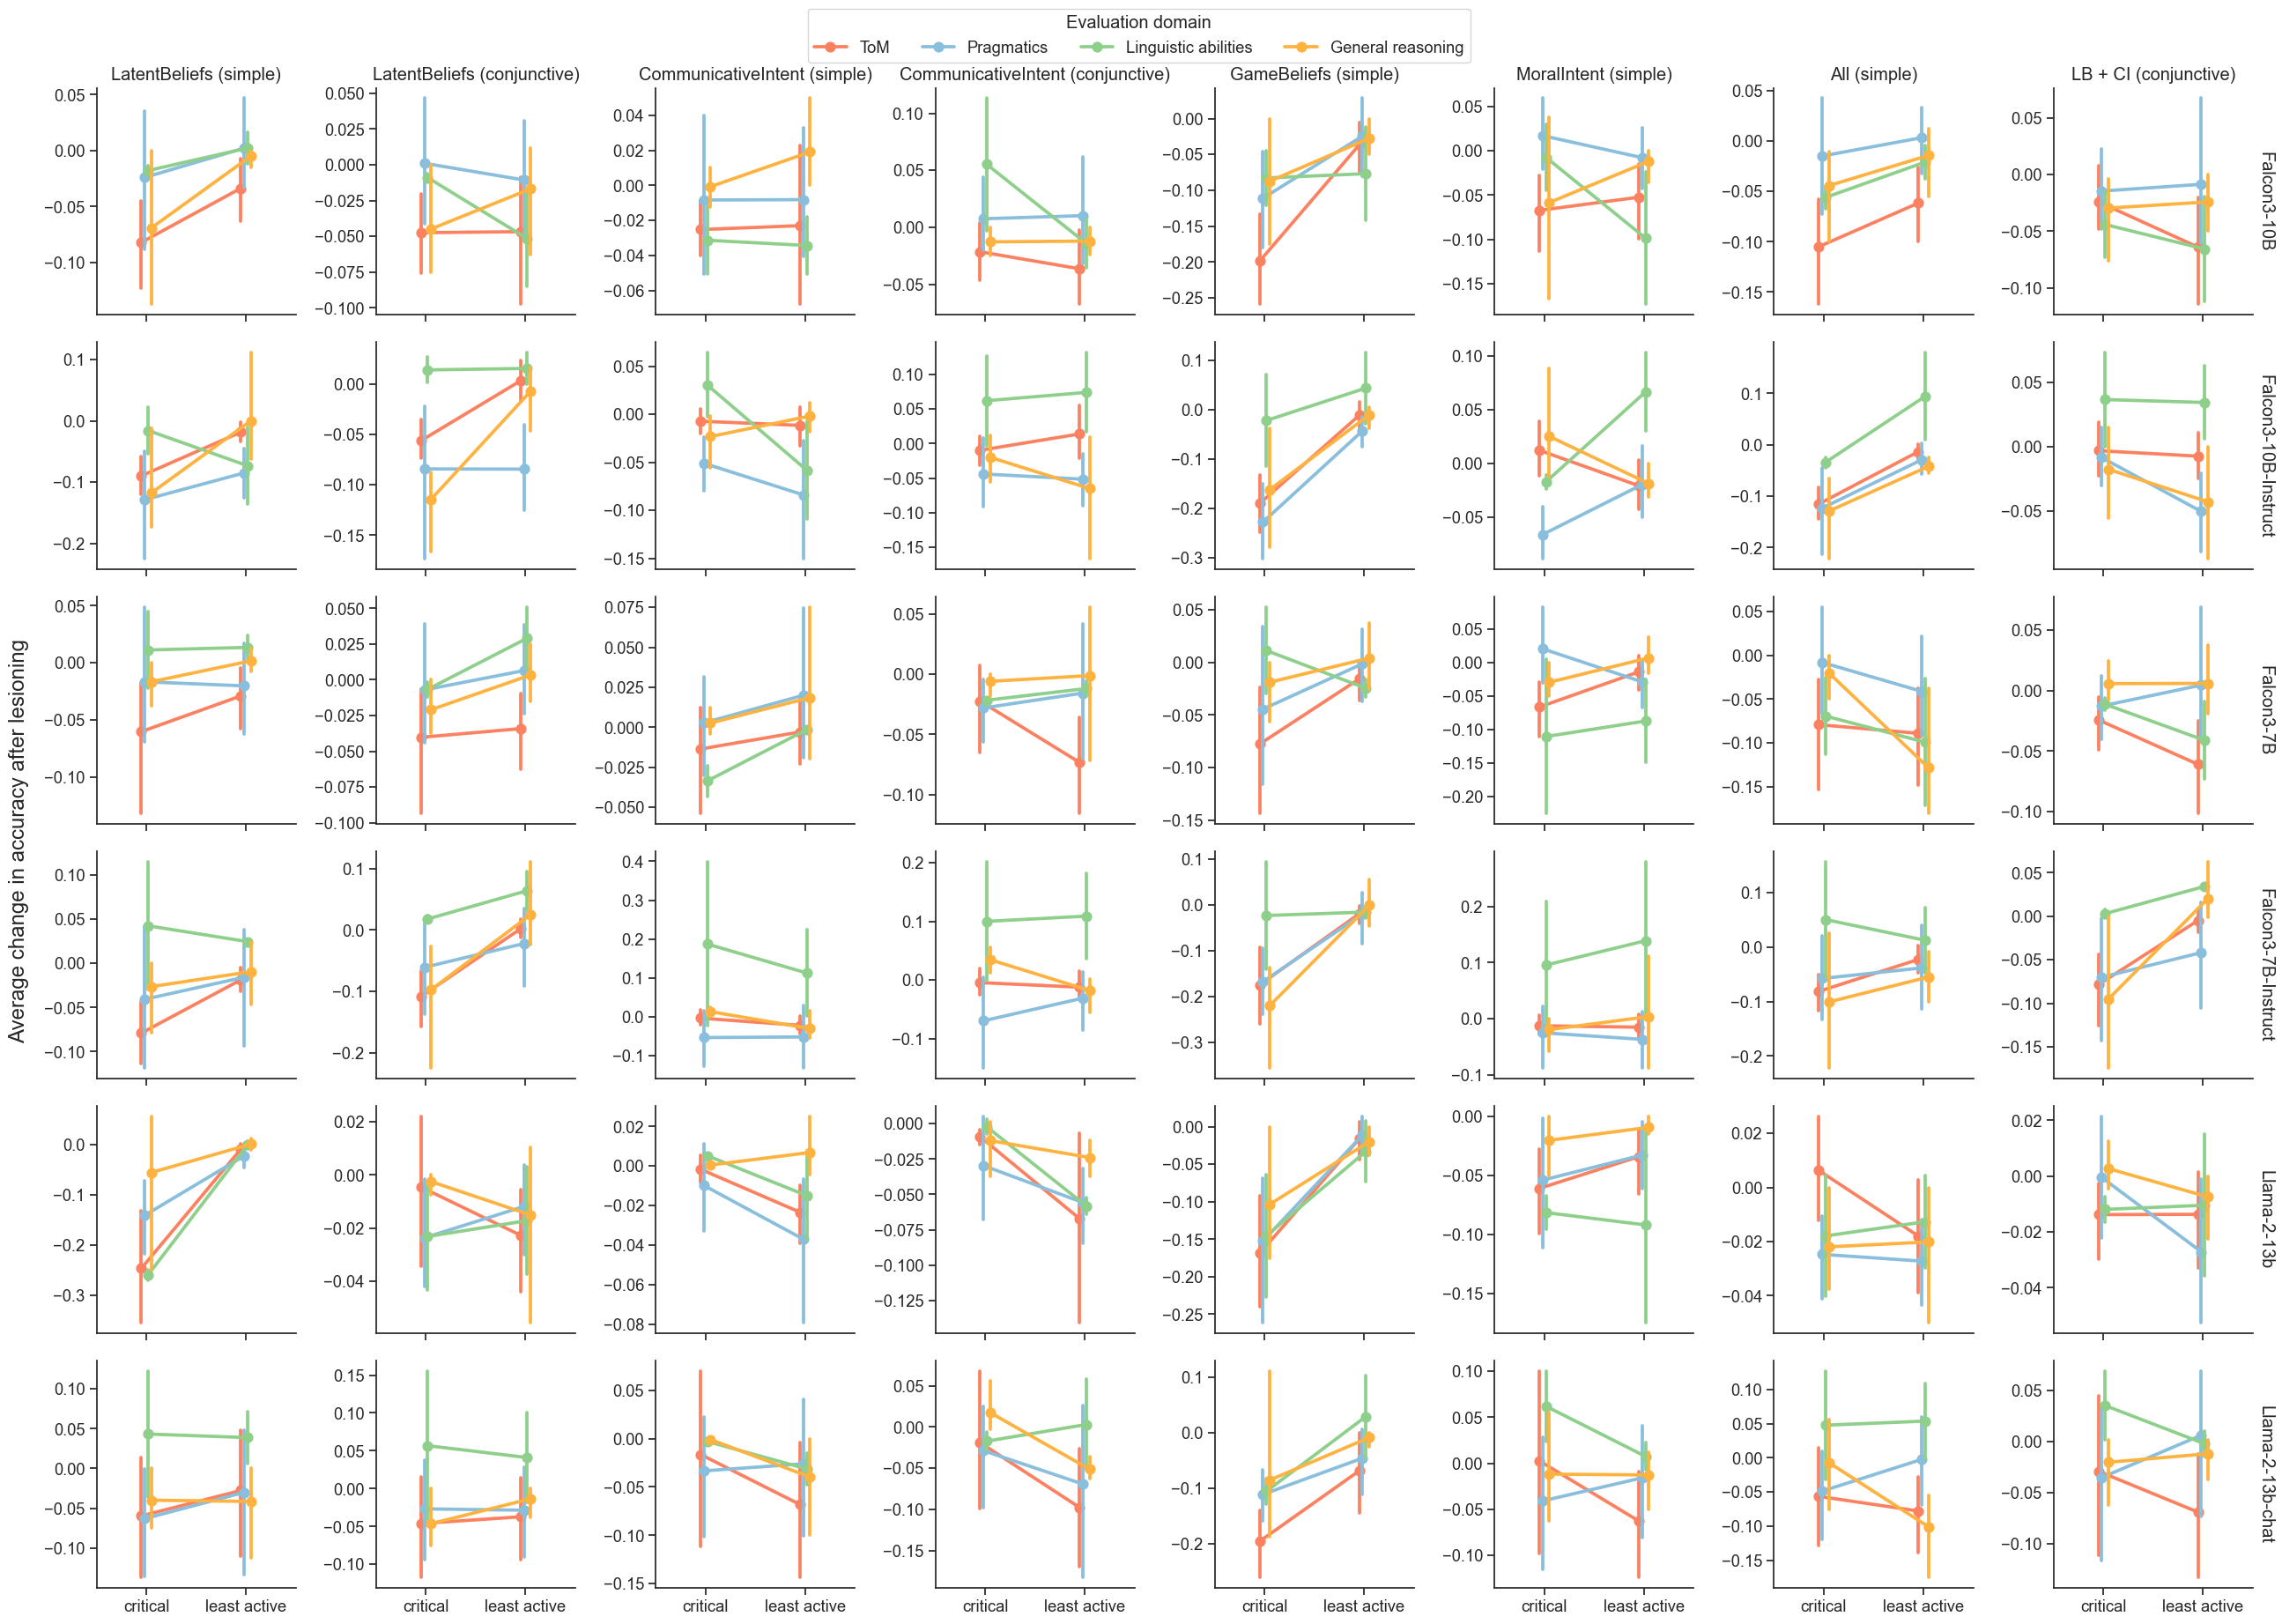

In [209]:
g_reb = sns.catplot(
    data=revisions_dataset_summary_noNa_part1,
    kind="point",
    x="localizer_type",
    y="delta_model_correct_mean",
    hue="domain",
    col="localizer",
    row="model",
    # col_wrap=4,
    # row_order=list(MODEL_MAP.values())[10:],
    col_order= ["LatentBeliefs (simple)", "LatentBeliefs (conjunctive)",  "CommunicativeIntent (simple)", "CommunicativeIntent (conjunctive)","GameBeliefs (simple)", "MoralIntent (simple)", "All (simple)","LB + CI (conjunctive)"],
    hue_order=["ToM", "Pragmatics", "Linguistic abilities", "General reasoning"],
    # markers=["^", "s", "o"],
    # palette=domain_colors,
    palette={
        "Pragmatics": blues[2],
        "ToM": reds[2],
        "Linguistic abilities": greens[2],
        "General reasoning": yellows[2]
    },
    dodge=True,
    errorbar=("ci", 95),
    height=3,
    aspect=1,
    legend=True,
    margin_titles=True,
    sharey=False
)
for ax in g_reb.axes.flatten():
    # ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        # label.set_ha('right')
    # ax.set_ylabel("Average change in accuracy after lesioning the subnetwork (across localizers)")
g_reb.set_titles(col_template="{col_name}", row_template="{row_name}")

sns.move_legend(
    g_reb,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),   # centered above the grid
    ncol=len(g_reb._legend_data),     # horizontal layout
    frameon=True,
    title="Evaluation domain"
)
# shared y-axis label
g_reb.fig.supylabel(
    "Average change in accuracy after lesioning",
    x=0.01  # tweak if needed
)
plt.tight_layout()
    

In [ ]:
# average across the controls
revisions_dataset_summary_noNa["domain_grouped"] = revisions_dataset_summary_noNa["domain"].apply(lambda x: x if x in ["ToM", "pragmatics"] else "control")

In [ ]:
g_reb = sns.catplot(
    data=revisions_dataset_summary_noNa,
    kind="point",
    x="localizer_type",
    y="delta_model_correct_mean",
    hue="domain_grouped",
    col="localizer",
    row="model",
    # col_wrap=4,
    # row_order=list(MODEL_MAP.values())[10:],
    # col_order= ["LatentBeliefs (simple)", "LatentBeliefs (conjunctive)",  "CommunicativeIntent (simple)", "CommunicativeIntent (conjunctive)","GameBeliefs (simple)", "MoralIntent (simple)", "All (simple)","LB + CI (conjunctive)"],
    hue_order=["ToM", "pragmatics", "control"],
    # markers=["^", "s", "o"],
    # palette={
    #     "pragmatics": blues[2],
    #     "ToM": reds[2],
    #     "syntax": greens[2],
    # },
    dodge=True,
    # errorbar=("ci", 95),
    height=3,
    aspect=1,
    legend=True,
    margin_titles=True,
    sharey=False
)
for ax in g_reb.axes.flatten():
    # ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        # label.set_ha('right')
    # ax.set_ylabel("Average change in accuracy after lesioning the subnetwork (across localizers)")
g_reb.set_titles(col_template="{col_name}", row_template="{row_name}")

sns.move_legend(
    g_reb,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),   # centered above the grid
    ncol=len(g_reb._legend_data),     # horizontal layout
    frameon=True,
    title="Evaluation domain"
)
# shared y-axis label
g_reb.fig.supylabel(
    "Average change in accuracy after lesioning the subnetwork",
    x=0.02  # tweak if needed
)
plt.tight_layout()
    